In [1]:
import pandas as pd
import numpy as np
from typing import List, Dict, Any
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, f1_score
from sklearn.model_selection import train_test_split
from datetime import datetime, timedelta
import mlflow
import matplotlib.pyplot as plt


from catboost import CatBoostClassifier, Pool
from scipy.optimize import linear_sum_assignment

c:\Users\MaharshiPatel\Downloads\Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#
FILE_PATH = "clean_13_year_data.xlsx"
JOIN_KEYS = ['UDC_BUYERDUNS', 'UDC_SELLERDUNS', 'UDC_DFC_PRODUCT', 'UDC_DFC_SHIPTO']

MIN_GROUP_SIZE = 100
NEGATIVE_RATIO = 5  # number of negative pairs per positive pair
TARGET = 'label'
CAT_FEATURES = JOIN_KEYS

# Toggles for optional steps
ENABLE_SHRINKAGE = False  # set False to disable Bayesian shrinkage
ENABLE_DIRECTIONAL_FEATURES = True
ENABLE_POSITIVE_AUGMENTATION = True
ENABLE_PROXIMITY_FEATURES = True
ENABLE_DATE_EXACT_EXTREME_NEGATIVES = True

PRIOR_STRENGTH = 20
# Positive-pair augmentation settings
AUGMENTATION_QTY_JITTER_PCT = 0.20   # perturb existing_qty by up to ±10%
AUGMENTATION_DATE_JITTER_DAYS = 3    # perturb existing_date by up to ±3 days
AUGMENTATION_COUNT = 2

DATE_EXACT_NEG_COUNT = 2             # synthetic negatives per positive pair
DATE_EXACT_NEG_QTY_RANGE = (5, 100)  # multiply existing_qty by random factor in this range

dtype_mapping = {
    'UDC_BUYERDUNS': str,
    'UDC_SELLERDUNS': str,
    'UDC_DFC_PRODUCT': str,
    'UDC_DFC_SHIPTO': str,
}

mlflow.set_experiment("Elemica")

<Experiment: artifact_location='file:c:/Users/MaharshiPatel/Downloads/Projects/mlruns/1', creation_time=1772705109853, experiment_id='1', last_update_time=1772705109853, lifecycle_stage='active', name='Elemica', tags={}, workspace='default'>

In [3]:
now = datetime.now()
df_raw = pd.read_excel(FILE_PATH, skiprows=0, dtype=dtype_mapping)

cols_to_keep = [
    'UDC_BUYERDUNS', 'UDC_SELLERDUNS', 'UDC_DFC_PRODUCT', 'UDC_DFC_SHIPTO',
    'UDC_DELIVERY_DATE', 'UDC_QTY', 'UDC_PREVIOUS_DELIVERY_DATE', 'UDC_PREVIOUS_QTY',
    'UDC_IMPORT_DATE', 'SNAPSHOT_DFC_DOCID_IMPORT_DATE',
]
df = df_raw[cols_to_keep].copy()

date_cols = ['UDC_DELIVERY_DATE', 'UDC_PREVIOUS_DELIVERY_DATE',
             'UDC_IMPORT_DATE', 'SNAPSHOT_DFC_DOCID_IMPORT_DATE']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

after = datetime.now()
print(f"Time taken to load data: {after - now}")

Time taken to load data: 0:05:21.398020


In [4]:
def label_rows(df_input: pd.DataFrame) -> pd.DataFrame:
    """Label each row as new-order (0), update (1), or edge-case (-1)."""
    df_res = df_input.copy()

    df_res['UDC_PREVIOUS_DELIVERY_DATE'] = df_res['UDC_PREVIOUS_DELIVERY_DATE'].dt.normalize()
    df_res['UDC_DELIVERY_DATE'] = df_res['UDC_DELIVERY_DATE'].dt.normalize()

    cond_new = (df_res['UDC_PREVIOUS_DELIVERY_DATE'].isna()) & \
               (df_res['UDC_PREVIOUS_QTY'].isna() | (df_res['UDC_PREVIOUS_QTY'] == 0))

    cond_update = (~cond_new) & \
                  ((df_res['UDC_DELIVERY_DATE'] != df_res['UDC_PREVIOUS_DELIVERY_DATE']) |
                   (df_res['UDC_QTY'] != df_res['UDC_PREVIOUS_QTY']))

    df_res['is_update'] = np.select([cond_new, cond_update], [0, 1], default=-1)
    return df_res


df = label_rows(df)

print("Row-level label distribution:")
print(df['is_update'].value_counts())

Row-level label distribution:
is_update
 0    216731
 1    106057
-1       139
Name: count, dtype: int64


In [5]:
df = df[df['is_update'] == 1].copy()

group_counts = df.groupby(JOIN_KEYS).size().rename('group_size')
groups_to_keep = group_counts[group_counts >= MIN_GROUP_SIZE].index
df = df.merge(pd.DataFrame(index=groups_to_keep), on=JOIN_KEYS, how='inner')

print(f"Groups with >= {MIN_GROUP_SIZE} records: {len(groups_to_keep)}")
print(f"Total records after group filter: {len(df)}")
print(df['is_update'].value_counts())

Groups with >= 100 records: 259
Total records after group filter: 58453
is_update
1    58453
Name: count, dtype: int64


In [6]:
def build_preliminary_kb(df_input: pd.DataFrame,
                         join_keys: List[str]) -> pd.DataFrame:
    """
    Compute lightweight per-group statistics from raw update rows.

    This runs BEFORE construct_pairs so that the pair-construction logic
    can use KB thresholds to generate KB-guided synthetic negatives for
    groups where the natural candidate pool lacks contrast.

    Only uses is_update==1 rows with valid previous values.
    """
    updates = df_input[df_input['is_update'] == 1].copy()
    updates = updates.dropna(subset=['UDC_PREVIOUS_DELIVERY_DATE', 'UDC_PREVIOUS_QTY'])

    updates['UDC_DELIVERY_DATE'] = pd.to_datetime(updates['UDC_DELIVERY_DATE'])
    updates['UDC_PREVIOUS_DELIVERY_DATE'] = pd.to_datetime(updates['UDC_PREVIOUS_DELIVERY_DATE'])

    eps = 1e-6
    updates['_qty_pct_change'] = (
        (updates['UDC_QTY'] - updates['UDC_PREVIOUS_QTY']).abs()
        / (updates['UDC_PREVIOUS_QTY'].abs() + eps)
    )
    updates['_date_diff_days'] = (
        (updates['UDC_DELIVERY_DATE'] - updates['UDC_PREVIOUS_DELIVERY_DATE']).dt.days.abs()
    )
    updates['_qty_direction'] = np.sign(updates['UDC_QTY'] - updates['UDC_PREVIOUS_QTY'])
    updates['_date_direction'] = np.sign(
        (updates['UDC_DELIVERY_DATE'] - updates['UDC_PREVIOUS_DELIVERY_DATE']).dt.days
    )

    kb = updates.groupby(join_keys).agg(
        prelim_qty_pct_mean=('_qty_pct_change', 'mean'),
        prelim_qty_pct_p95=('_qty_pct_change', lambda x: x.quantile(0.95)),
        prelim_qty_pct_p99=('_qty_pct_change', lambda x: x.quantile(0.99)),
        prelim_date_diff_p95=('_date_diff_days', lambda x: x.quantile(0.95)),
        prelim_date_diff_p99=('_date_diff_days', lambda x: x.quantile(0.99)),
        prelim_frac_qty_increase=('_qty_direction', lambda x: (x > 0).mean()),
        prelim_frac_postpone=('_date_direction', lambda x: (x > 0).mean()),
        prelim_n_updates=('_qty_pct_change', 'count'),
    ).reset_index()

    kb['prelim_qty_veto_T'] = np.maximum(
        kb['prelim_qty_pct_p99'], 2 * kb['prelim_qty_pct_p95']
    )
    kb['prelim_date_veto_T'] = np.maximum(
        kb['prelim_date_diff_p99'], 2 * kb['prelim_date_diff_p95']
    )

    print(f"Preliminary KB: {len(kb)} groups")
    return kb

In [7]:
def construct_pairs_with_kb(df_input: pd.DataFrame,
                    join_keys: List[str],
                    neg_ratio: int = 5,
                    n_date_close_qty_far: int = 3,
                    n_qty_close_date_far: int = 2,
                    random_state: int = 42,
                    add_exact_date_qty_extreme: bool = True,
                    df_kb: pd.DataFrame = None,
                    kb_fallback_threshold: float = 0.5) -> pd.DataFrame:
    """
    Build a training dataset of (forecast_line, existing_order) pairs.

    Positive pairs: from rows where is_update==1, the current values are the
    "forecast side" and the previous values are the "existing order side".

    Negative pairs use two-stage contrastive selection (per positive pair):
      - Type A: date-close but qty-FAR (forces model to learn qty signal)
      - Type B: qty-close but date-FAR (reinforces date signal)
      - Random: broad coverage

    KB-guided synthetic fallback:
      When df_kb is provided and natural candidates lack contrast on a
      dimension (best natural contrast < kb_fallback_threshold * group p95),
      Type A / Type B slots are replaced with KB-calibrated synthetic
      negatives.  This guarantees meaningful training signal even for
      groups with extremely tight qty or date distributions.

      Synthetic Type A: existing_date = true match date (date features ≈ 0),
        existing_qty perturbed at 2×p95, veto_T, and 3×veto_T scales.
      Synthetic Type B: existing_qty = true match qty (qty features ≈ 0),
        existing_date shifted by p95, veto_T, and 3×veto_T days.
    """
    rng = np.random.RandomState(random_state)
    
    # --- COMMENTED OUT RANDOM NEGATIVE CALCULATION ---
    # n_random = neg_ratio - n_date_close_qty_far - n_qty_close_date_far
    n_random = 0 # Set to 0 to ensure no random slots are allocated

    updates = df_input[df_input['is_update'] == 1].copy()
    updates = updates.dropna(subset=['UDC_PREVIOUS_DELIVERY_DATE', 'UDC_PREVIOUS_QTY'])

    positives = updates[
        join_keys + [
            'UDC_DELIVERY_DATE', 'UDC_QTY',
            'UDC_PREVIOUS_DELIVERY_DATE', 'UDC_PREVIOUS_QTY',
            'SNAPSHOT_DFC_DOCID_IMPORT_DATE',
        ]
    ].copy()
    positives.rename(columns={
        'UDC_DELIVERY_DATE': 'forecast_date',
        'UDC_QTY': 'forecast_qty',
        'UDC_PREVIOUS_DELIVERY_DATE': 'existing_date',
        'UDC_PREVIOUS_QTY': 'existing_qty',
    }, inplace=True)
    positives[TARGET] = 1

    existing_pool = updates.groupby(join_keys).apply(
        lambda g: g[['UDC_PREVIOUS_DELIVERY_DATE', 'UDC_PREVIOUS_QTY']].drop_duplicates()
    ).reset_index()

    existing_pool.rename(columns={
        'UDC_PREVIOUS_DELIVERY_DATE': 'existing_date',
        'UDC_PREVIOUS_QTY': 'existing_qty',
    }, inplace=True)
    
    if 'level_4' in existing_pool.columns:
        existing_pool.drop(columns=['level_4'], inplace=True)
        
    extra_level_cols = [c for c in existing_pool.columns if c.startswith('level_')]
    if extra_level_cols:
        existing_pool.drop(columns=extra_level_cols, inplace=True)

    kb_index = None
    if df_kb is not None:
        kb_index = df_kb.set_index(join_keys)

    n_synthetic_type_a = 0
    n_synthetic_type_b = 0

    negative_rows = []
    for _, pos_row in positives.iterrows():
        group_key = tuple(pos_row[k] for k in join_keys)

        mask = True
        for i, k in enumerate(join_keys):
            mask = mask & (existing_pool[k] == group_key[i])
        group_pool = existing_pool[mask]

        candidates = group_pool[
            ~((group_pool['existing_date'] == pos_row['existing_date']) &
              (group_pool['existing_qty'] == pos_row['existing_qty']))
        ]

        if len(candidates) == 0:
            continue

        cands = candidates.copy()
        cands['_date_dist'] = (cands['existing_date'] - pos_row['existing_date']).dt.days.abs()
        cands['_qty_pct_dist'] = (
            (cands['existing_qty'] - pos_row['existing_qty']).abs()
            / (abs(pos_row['existing_qty']) + 1e-6)
        )

        kb_row = None
        if kb_index is not None:
            try:
                kb_row = kb_index.loc[group_key]
            except KeyError:
                pass

        # --- Type A Logic ---
        use_synthetic_a = False
        if kb_row is not None:
            best_natural_qty_contrast = cands['_qty_pct_dist'].max()
            group_qty_p95 = kb_row['prelim_qty_pct_p95']
            if best_natural_qty_contrast < kb_fallback_threshold * group_qty_p95:
                use_synthetic_a = True

        if use_synthetic_a:
            qty_veto_T = kb_row['prelim_qty_veto_T']
            qty_p95 = kb_row['prelim_qty_pct_p95']
            frac_inc = kb_row.get('prelim_frac_qty_increase', 0.5)
            dominant_sign = -1 if frac_inc < 0.5 else 1
            synth_scales = [dominant_sign * 2 * qty_p95, dominant_sign * qty_veto_T, -dominant_sign * qty_veto_T][:n_date_close_qty_far]

            for scale in synth_scales:
                neg_row = {k: pos_row[k] for k in join_keys}
                neg_row.update({'forecast_date': pos_row['forecast_date'], 'forecast_qty': pos_row['forecast_qty'], 'existing_date': pos_row['existing_date'], 'existing_qty': max(pos_row['existing_qty'] * (1 + scale), 1), 'SNAPSHOT_DFC_DOCID_IMPORT_DATE': pos_row['SNAPSHOT_DFC_DOCID_IMPORT_DATE'], TARGET: 0})
                negative_rows.append(neg_row)
            n_synthetic_type_a += len(synth_scales)
            type_a_idx = pd.Index([])
        else:
            date_pool_size = max(len(cands) // 2, n_date_close_qty_far * 3)
            date_close_pool = cands.nsmallest(min(date_pool_size, len(cands)), '_date_dist')
            type_a = date_close_pool.nlargest(min(n_date_close_qty_far, len(date_close_pool)), '_qty_pct_dist')
            type_a_idx = type_a.index

        # --- Type B Logic ---
        use_synthetic_b = False
        if kb_row is not None:
            best_natural_date_contrast = cands['_date_dist'].max()
            group_date_p95 = kb_row['prelim_date_diff_p95']
            if best_natural_date_contrast < kb_fallback_threshold * group_date_p95:
                use_synthetic_b = True

        if use_synthetic_b:
            date_veto_T = kb_row['prelim_date_veto_T']
            date_p95 = kb_row['prelim_date_diff_p95']
            frac_post = kb_row.get('prelim_frac_postpone', 0.5)
            date_sign = -1 if frac_post < 0.5 else 1
            synth_date_shifts = [date_sign * int(max(date_veto_T, 2 * date_p95))][:n_qty_close_date_far]

            for shift_days in synth_date_shifts:
                neg_row = {k: pos_row[k] for k in join_keys}
                neg_row.update({'forecast_date': pos_row['forecast_date'], 'forecast_qty': pos_row['forecast_qty'], 'existing_date': pos_row['existing_date'] + pd.Timedelta(days=shift_days), 'existing_qty': pos_row['existing_qty'], 'SNAPSHOT_DFC_DOCID_IMPORT_DATE': pos_row['SNAPSHOT_DFC_DOCID_IMPORT_DATE'], TARGET: 0})
                negative_rows.append(neg_row)
            n_synthetic_type_b += len(synth_date_shifts)
            type_b_idx = pd.Index([])
        else:
            remaining = cands.drop(type_a_idx, errors='ignore')
            if len(remaining) > 0 and n_qty_close_date_far > 0:
                qty_pool_size = max(len(remaining) // 2, n_qty_close_date_far * 3)
                qty_close_pool = remaining.nsmallest(min(qty_pool_size, len(remaining)), '_qty_pct_dist')
                type_b = qty_close_pool.nlargest(min(n_qty_close_date_far, len(qty_close_pool)), '_date_dist')
                type_b_idx = type_b.index
            else:
                type_b_idx = pd.Index([])

        # --- COMMENTED OUT RANDOM FROM THE REST ---
        used_idx = type_a_idx.union(type_b_idx)
        leftover = cands.drop(used_idx, errors='ignore')
        # n_rand = min(n_random, len(leftover))
        # if n_rand > 0:
        #     type_c = leftover.sample(n=n_rand, random_state=rng)
        # else:
        #     type_c = cands.iloc[:0]
        type_c = cands.iloc[:0] # Placeholder for empty random set

        # Collect natural negatives
        natural_parts = [type_c]
        if not use_synthetic_a and len(type_a_idx) > 0:
            natural_parts.append(cands.loc[type_a_idx])
        if not use_synthetic_b and len(type_b_idx) > 0:
            natural_parts.append(cands.loc[type_b_idx])

        sampled = pd.concat(natural_parts).drop(columns=['_date_dist', '_qty_pct_dist'], errors='ignore') if natural_parts else cands.iloc[:0]

        # Optional: exact-date but qty-extreme logic (Kept as it is not 'random')
        if add_exact_date_qty_extreme and len(leftover) > 0:
            exact_date = leftover[leftover['existing_date'] == pos_row['existing_date']]
            if len(exact_date) == 0:
                exact_date = leftover[leftover['_date_dist'] <= 1]
            if len(exact_date) > 0:
                exact_date = exact_date.assign(_qty_pct_dist=((exact_date['existing_qty'] - pos_row['existing_qty']).abs() / (abs(pos_row['existing_qty']) + 1e-6)))
                exact_pick = exact_date.nlargest(1, '_qty_pct_dist').drop(columns=['_date_dist', '_qty_pct_dist'], errors='ignore')
                sampled = pd.concat([sampled, exact_pick], ignore_index=False)

        for _, neg_existing in sampled.iterrows():
            neg_row = {k: pos_row[k] for k in join_keys}
            neg_row.update({'forecast_date': pos_row['forecast_date'], 'forecast_qty': pos_row['forecast_qty'], 'existing_date': neg_existing['existing_date'], 'existing_qty': neg_existing['existing_qty'], 'SNAPSHOT_DFC_DOCID_IMPORT_DATE': pos_row['SNAPSHOT_DFC_DOCID_IMPORT_DATE'], TARGET: 0})
            negative_rows.append(neg_row)

    negatives = pd.DataFrame(negative_rows)
    pairs = pd.concat([positives, negatives], ignore_index=True)
    pairs = pairs.sort_values('SNAPSHOT_DFC_DOCID_IMPORT_DATE').reset_index(drop=True)

    # Logging...

    print(f"Positive pairs: {len(positives)}")
    print(f"Negative pairs: {len(negatives)}")
    print(f"  Natural negatives: {len(negatives) - n_synthetic_type_a - n_synthetic_type_b}")
    print(f"  KB-synthetic Type A (qty-contrast): {n_synthetic_type_a}")
    print(f"  KB-synthetic Type B (date-contrast): {n_synthetic_type_b}")
    print(f"  (target per positive: {n_date_close_qty_far} type-a + "
          f"{n_qty_close_date_far} type-b + {n_random} random "
          f"+ exact-date-extreme={add_exact_date_qty_extreme})")
    print(f"Total pairs: {len(pairs)}")
    return pairs

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58453 entries, 0 to 58452
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   UDC_BUYERDUNS                   58453 non-null  object        
 1   UDC_SELLERDUNS                  58453 non-null  object        
 2   UDC_DFC_PRODUCT                 58453 non-null  object        
 3   UDC_DFC_SHIPTO                  58453 non-null  object        
 4   UDC_DELIVERY_DATE               58453 non-null  datetime64[ns]
 5   UDC_QTY                         58453 non-null  float64       
 6   UDC_PREVIOUS_DELIVERY_DATE      58453 non-null  datetime64[ns]
 7   UDC_PREVIOUS_QTY                58453 non-null  float64       
 8   UDC_IMPORT_DATE                 58453 non-null  datetime64[ns]
 9   SNAPSHOT_DFC_DOCID_IMPORT_DATE  58453 non-null  datetime64[ns]
 10  is_update                       58453 non-null  int64         
dtypes:

In [9]:
# print("\n--- Building Preliminary KB (for synthetic negative guidance) ---")
# df_prelim_kb = build_preliminary_kb(df, JOIN_KEYS)

# print("\n--- Constructing Pairs ---")
# df_pairs = construct_pairs_with_kb(df, JOIN_KEYS, neg_ratio=NEGATIVE_RATIO, df_kb=df_prelim_kb)

# df_pairs.to_csv('kb_pairs/df_pairs.csv', index=False)
# df_prelim_kb.to_csv('kb_pairs/df_prelim_kb.csv', index=False)

df_prelim_kb = pd.read_csv('kb_pairs\df_prelim_kb.csv')
df_pairs = pd.read_csv('kb_pairs\df_pairs.csv')

<>:10: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:11: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:10: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:11: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\MaharshiPatel\AppData\Local\Temp\ipykernel_24504\2875239378.py:10: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df_prelim_kb = pd.read_csv('kb_pairs\df_prelim_kb.csv')
C:\Users\MaharshiPatel\AppData\Local\Temp\ipykernel_24504\2875239378.py:11: SyntaxWarning: "\d" is an i

#### Debuging the Negative Samples Generation

In [10]:
df_pairs.head()

,UDC_BUYERDUNS,UDC_SELLERDUNS,UDC_DFC_PRODUCT,UDC_DFC_SHIPTO,forecast_date,forecast_qty,existing_date,existing_qty,SNAPSHOT_DFC_DOCID_IMPORT_DATE,label
0,0013168270001,282989110,96211456,4856,2015-02-02,25000.0,2015-02-06,25000.0,2015-01-26 09:30:32,0
1,0013168270001,282989110,96211456,4856,2015-02-03,25000.0,2015-02-06,25000.0,2015-01-26 09:30:32,0
2,0013168270001,282989110,96211456,4856,2015-02-02,25000.0,2018-08-01,25000.0,2015-01-26 09:30:32,0
3,0013168270001,282989110,96211456,4856,2015-02-02,25000.0,2015-01-26,25000.0,2015-01-26 09:30:32,0
4,0013168270001,282989110,96211456,4856,2015-02-02,25000.0,2018-08-02,25000.0,2015-01-26 09:30:32,0


In [11]:
# # Understanding how particular group had -ve samples 
# # 3153699342000	480150752	0452968-00	020;22950
# sample1_abs_date_diff_days = df_pairs[(df_pairs['UDC_BUYERDUNS'] == '001316827') & (df_pairs['UDC_SELLERDUNS'] == '001307032') & (df_pairs['UDC_DFC_PRODUCT'] == '000000000090760543') & (df_pairs['UDC_DFC_SHIPTO'] == '1731') & (df_pairs['label'] == 0)]['abs_date_diff_days'].copy()
# sample1_abs_qty_pct_change = df_pairs[(df_pairs['UDC_BUYERDUNS'] == '001316827') & (df_pairs['UDC_SELLERDUNS'] == '001307032') & (df_pairs['UDC_DFC_PRODUCT'] == '000000000090760543') & (df_pairs['UDC_DFC_SHIPTO'] == '1731') & (df_pairs['label'] == 0)]['abs_qty_pct_change'].copy()
# print(f"Info of abs_date_diff_days :\n {sample1_abs_date_diff_days.describe()}")
# print(f"\nInfo of abs_date_diff_days :\n {sample1_abs_qty_pct_change.describe()}")
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# axes[0].hist(sample1_abs_qty_pct_change, bins=15, color='skyblue', edgecolor='black')
# axes[0].set_title('Quantity % Change')
# axes[0].set_xlabel('Absolute Quantity % Change')
# axes[0].set_ylabel('Frequency')
# axes[0].grid(axis='y', alpha=0.75)

# axes[1].hist(sample1_abs_date_diff_days, bins=15, color='lightgreen', edgecolor='black')
# axes[1].set_title('Date Difference in Days')
# axes[1].set_xlabel('Absolute Date Difference (Days)')
# axes[1].set_ylabel('Frequency')
# axes[1].grid(axis='y', alpha=0.75)

# plt.tight_layout()
# plt.show()

In [12]:
# # Understanding how particular group had +ve samples (TP)
# sample2_abs_date_diff_days = df_pairs[(df_pairs['UDC_BUYERDUNS'] == '3153699342000') & (df_pairs['UDC_SELLERDUNS'] == '480150752') & (df_pairs['UDC_DFC_PRODUCT'] == '0452968-00') & (df_pairs['UDC_DFC_SHIPTO'] == '020;22950') & (df_pairs['label'] == 1)]['abs_date_diff_days'].copy()
# sample2_abs_qty_pct_change = df_pairs[(df_pairs['UDC_BUYERDUNS'] == '3153699342000') & (df_pairs['UDC_SELLERDUNS'] == '480150752') & (df_pairs['UDC_DFC_PRODUCT'] == '0452968-00') & (df_pairs['UDC_DFC_SHIPTO'] == '020;22950') & (df_pairs['label'] == 1)]['abs_qty_pct_change'].copy()
# print(f"Info of abs_date_diff_days :\n {sample2_abs_date_diff_days.describe()}")
# print(f"\nInfo of abs_date_diff_days :\n {sample2_abs_qty_pct_change.describe()}")
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# axes[0].hist(sample2_abs_qty_pct_change, bins=10, color='skyblue', edgecolor='black')
# axes[0].set_title('Quantity % Change')
# axes[0].set_xlabel('Absolute Quantity % Change')
# axes[0].set_ylabel('Frequency')
# axes[0].grid(axis='y', alpha=0.75)

# axes[1].hist(sample2_abs_date_diff_days, bins=10, color='lightgreen', edgecolor='black')
# axes[1].set_title('Date Difference in Days')
# axes[1].set_xlabel('Absolute Date Difference (Days)')
# axes[1].set_ylabel('Frequency')
# axes[1].grid(axis='y', alpha=0.75)

# plt.tight_layout()
# plt.show()

In [13]:
# all_data_with_synthetic_negatives_path = r"D:\TenupProjects\elemica\df_pairs_with_kb.csv"
# df_pairs.to_csv(all_data_with_synthetic_negatives_path, index=False)

In [14]:
# df_pairs = pd.read_csv(r"D:\TenupProjects\elemica\df_pairs_with_kb.csv", skiprows=0, dtype=dtype_mapping)

In [15]:
def engineer_pair_features(df_pairs: pd.DataFrame) -> pd.DataFrame:
    """
    Compute features that describe the relationship between a forecast line
    and a candidate existing order. All difference features use log-space
    to handle heavy-tailed distributions.
    """
    df = df_pairs.copy()

    df['forecast_date'] = pd.to_datetime(df['forecast_date'], errors='coerce')
    df['existing_date'] = pd.to_datetime(df['existing_date'], errors='coerce')

    # df['date_diff_days'] = (df['forecast_date'] - df['existing_date']).dt.days
    # df['abs_date_diff_days'] = df['date_diff_days'].abs()

    # df['qty_diff'] = df['forecast_qty'] - df['existing_qty']
    # df['abs_qty_diff'] = df['qty_diff'].abs()
    date_diff_days = (df['forecast_date'] - df['existing_date']).dt.days
    qty_diff = df['forecast_qty'] - df['existing_qty']
    df['abs_date_diff_days'] = date_diff_days.abs()

    eps = 1e-6
    df['qty_ratio'] = df['forecast_qty'] / (df['existing_qty'] + eps)
    df['abs_qty_pct_change'] = qty_diff.abs() / (df['existing_qty'].abs() + eps)

    # df['date_diff_log'] = np.sign(df['date_diff_days']) * np.log1p(df['date_diff_days'].abs())
    # df['qty_diff_log'] = np.sign(df['qty_diff']) * np.log1p(df['qty_diff'].abs())
    df['date_diff_log'] = np.sign(date_diff_days) * np.log1p(date_diff_days.abs())
    df['qty_diff_log'] = np.sign(qty_diff) * np.log1p(qty_diff.abs())

    df['abs_log_qty_ratio'] = np.abs(np.log(df['qty_ratio'].clip(lower=1e-6)))

    return df


print("\n--- Engineering Pair Features ---")
df_pairs = engineer_pair_features(df_pairs)


--- Engineering Pair Features ---


#### Analysis of Data before TTS

In [16]:
df['is_update'].value_counts()

is_update
1    58453
Name: count, dtype: int64

In [17]:
print(f"Count of label = 1 for abs_date_diff_days = 0 and abs_qty_pct_change = 0: {df_pairs[(df_pairs['abs_date_diff_days'] == 0) & (df_pairs['abs_qty_pct_change'] == 0) & (df_pairs['label'] == 1)].shape[0]}")
print(df_pairs['label'].value_counts())
df_pairs[(df_pairs['abs_date_diff_days'] == 0) & (df_pairs['abs_qty_pct_change'] > 0)]['abs_qty_pct_change'].describe()
df_pairs[(df_pairs['abs_date_diff_days'] == 0) & (df_pairs['abs_qty_pct_change'] > 0)]['abs_qty_pct_change'].max()

Count of label = 1 for abs_date_diff_days = 0 and abs_qty_pct_change = 0: 0
label
0    309331
1     58453
Name: count, dtype: int64


np.float64(359998.64000136004)

In [18]:
target_df = df_pairs.copy()

print("Count of abs_qty_pct_change = 0: {:d} ({:.2f}%)".format(target_df[target_df['abs_qty_pct_change'] == 0].shape[0], target_df[target_df['abs_qty_pct_change'] == 0].shape[0] / target_df.shape[0] * 100))
print("Count of abs_date_diff_days = 0: {:d} ({:.2f}%)".format(target_df[target_df['abs_date_diff_days'] == 0].shape[0], target_df[target_df['abs_date_diff_days'] == 0].shape[0] / target_df.shape[0] * 100))
print("Count of abs_qty_pct_chnage = 0 and abs_date_diff_days = 0: {:d} ({:.2f}%)".format(target_df[(target_df['abs_qty_pct_change'] == 0) & (target_df['abs_date_diff_days'] == 0)].shape[0], target_df[(target_df['abs_qty_pct_change'] == 0) & (target_df['abs_date_diff_days'] == 0)].shape[0] / target_df.shape[0] * 100))

eps = 1e-6
neg = target_df[target_df['label'] == 0]
pos_count = (target_df['label'] == 1).sum()

if len(neg) > 0:
    print("Negative sampels analysis\nQty (% change):  mean = {:.4f}  |  p95 = {:.4f}  |  p99 = {:.4f}".format(
        neg['abs_qty_pct_change'].mean(), neg['abs_qty_pct_change'].quantile(0.95), neg['abs_qty_pct_change'].quantile(0.99)))
    print("Date (days):     mean = {:.1f}  |  p95 = {:.1f}  |  p99 = {:.1f}".format(
        neg['abs_date_diff_days'].mean(), neg['abs_date_diff_days'].quantile(0.95), neg['abs_date_diff_days'].quantile(0.99)))

DATE_CLOSE_DAYS = 7
QTY_FAR_PCT = 0.2

type_a_like = (neg['abs_date_diff_days'] <= DATE_CLOSE_DAYS) & (neg['abs_qty_pct_change'] > QTY_FAR_PCT)
type_b_like = (neg['abs_qty_pct_change'] <= QTY_FAR_PCT) & (neg['abs_date_diff_days'] > DATE_CLOSE_DAYS)
exact_date_extreme = (neg['abs_date_diff_days'] <= 1) & (neg['abs_qty_pct_change'] > QTY_FAR_PCT)

print(f"\n=== Thresholds: date_close<={DATE_CLOSE_DAYS}d, qty_far>{QTY_FAR_PCT*100}%) ===")
print("  Type A–like (date-close, qty-far):  {:5d}  ({:.1f}%)".format(type_a_like.sum(), 100*type_a_like.mean()))
print("  Type B–like (qty-close, date-far):  {:5d}  ({:.1f}%)".format(type_b_like.sum(), 100*type_b_like.mean()))
print("  Exact-date qty-extreme (date<=1d):  {:5d}  ({:.1f}%)".format(exact_date_extreme.sum(), 100*exact_date_extreme.mean()))

print("\n=== Counts ===")
print("  Positives: {}  |  Negatives: {}  |  Negatives per positive: {:.2f}".format(pos_count, len(neg), len(neg)/(pos_count or 1)))
print("  Negatives with exact date (|date_diff_days|<=1): {} ({:.1f}%)".format((neg['abs_date_diff_days'] <= 1).sum(), 100*(neg['abs_date_diff_days'] <= 1).mean()))

Count of abs_qty_pct_change = 0: 112935 (30.71%)
Count of abs_date_diff_days = 0: 26849 (7.30%)
Count of abs_qty_pct_chnage = 0 and abs_date_diff_days = 0: 2423 (0.66%)
Negative sampels analysis
Qty (% change):  mean = 636.8016  |  p95 = 5.6667  |  p99 = 20410.9796
Date (days):     mean = 644.7  |  p95 = 2254.0  |  p99 = 3122.0

=== Thresholds: date_close<=7d, qty_far>20.0%) ===
  Type A–like (date-close, qty-far):  18091  (5.8%)
  Type B–like (qty-close, date-far):  107361  (34.7%)
  Exact-date qty-extreme (date<=1d):   8980  (2.9%)

=== Counts ===
  Positives: 58453  |  Negatives: 309331  |  Negatives per positive: 5.29
  Negatives with exact date (|date_diff_days|<=1): 15126 (4.9%)


In [19]:
def split_group_wise_pairs_chronologically(
        df_pairs: pd.DataFrame,
        time_col: str = 'SNAPSHOT_DFC_DOCID_IMPORT_DATE',
        test_size: float = 0.2
):
    grouped = df_pairs.groupby(['UDC_BUYERDUNS', 'UDC_SELLERDUNS', 'UDC_DFC_PRODUCT', 'UDC_DFC_SHIPTO'])
    df_train = pd.DataFrame()
    df_test = pd.DataFrame()
    total_data = 0
    for i, (group_key, group_data) in enumerate(grouped):
        total_data += len(group_data)

        sorted_group_data = group_data.sort_values(by=time_col).reset_index(drop=True)
        split_idx = int(len(sorted_group_data) * (1 - test_size))
        group_df_train = sorted_group_data.iloc[:split_idx].copy()
        group_df_test = sorted_group_data.iloc[split_idx:].copy()

        df_train = pd.concat([df_train, group_df_train])
        df_test = pd.concat([df_test, group_df_test])

        # print(f"Group Key: {group_key}")
        # print(f"Length of data: {len(group_data)}")

    print(f"Total data in df_pairs= {total_data}")
    print(f"Chronological split: Train={len(df_train)} | Test={len(df_test)}")
    return df_train, df_test

In [20]:
def test_groups_diff_in_train_test(
        df_train: pd.DataFrame,
        df_test: pd.DataFrame
):
    group_cols = ['UDC_BUYERDUNS', 'UDC_SELLERDUNS', 'UDC_DFC_PRODUCT', 'UDC_DFC_SHIPTO']
    train_group_counts = df_train.groupby(group_cols).size()
    test_group_counts = df_test.groupby(group_cols).size()

    # Groups present in train but not in test
    count_train_only = len(train_group_counts.index.difference(test_group_counts.index))

    # Groups present in test but not in train
    count_test_only = len(test_group_counts.index.difference(train_group_counts.index))

    print(f"Groups in train but not in test: {count_train_only}")
    print(f"Groups in test but not in train: {count_test_only}")

In [21]:
def split_pairs_chronologically(df_pairs: pd.DataFrame,
                                time_col: str = 'SNAPSHOT_DFC_DOCID_IMPORT_DATE',
                                test_size: float = 0.2):
    df_sorted = df_pairs.sort_values(by=time_col).reset_index(drop=True)
    split_idx = int(len(df_sorted) * (1 - test_size))
    df_train = df_sorted.iloc[:split_idx].copy()
    df_test = df_sorted.iloc[split_idx:].copy()
    print(f"Chronological split: Train={len(df_train)} | Test={len(df_test)}")
    return df_train, df_test


print("\n--- Splitting Data ---")
df_train_pairs, df_test_pairs = split_pairs_chronologically(df_pairs)
test_groups_diff_in_train_test(df_train=df_train_pairs, df_test=df_test_pairs)


--- Splitting Data ---


Chronological split: Train=294227 | Test=73557
Groups in train but not in test: 84
Groups in test but not in train: 2


In [22]:
print("\n===== Splitting Data Groupwise =========")
group_df_train_pairs, group_df_test_pairs = split_group_wise_pairs_chronologically(df_pairs=df_pairs)
test_groups_diff_in_train_test(df_train=group_df_train_pairs, df_test=group_df_test_pairs)


===== Splitting Data Groupwise =========
Total data in df_pairs= 367784
Chronological split: Train=294122 | Test=73662
Groups in train but not in test: 0
Groups in test but not in train: 0


In [23]:
def augment_positive_pairs(df_train: pd.DataFrame,
                           join_keys: List[str],
                           target_col: str = TARGET,
                           n_augmented: int = AUGMENTATION_COUNT,
                           qty_jitter_pct: float = AUGMENTATION_QTY_JITTER_PCT,
                           date_jitter_days: int = AUGMENTATION_DATE_JITTER_DAYS,
                           qty_zero_threshold: float = 0.01,
                           random_state: int = 42) -> pd.DataFrame:
    """
    Break the binary qty_diff=0 cliff by adding synthetic positive pairs
    with small perturbations to existing_qty and existing_date.

    Only augments "zero-change" positives (where abs_qty_pct_change < threshold
    AND abs_date_diff_days <= 1). These are the pairs that create the binary
    cliff — the model sees qty_diff==0 as a near-perfect proxy for "correct
    match." Positives that already have non-zero changes don't need augmentation
    and including them would dilute the zero-change signal.

    Only applied to TRAINING data to avoid test-set contamination.
    Returns the concatenated DataFrame (original + augmented).
    """
    rng = np.random.RandomState(random_state)
    positives = df_train[df_train[target_col] == 1].copy()

    is_qty_near_zero = positives['abs_qty_pct_change'] < qty_zero_threshold
    is_date_near_zero = positives['abs_date_diff_days'] <= 1
    zero_change_mask = is_qty_near_zero & is_date_near_zero

    zero_change_positives = positives[zero_change_mask]
    n_zero = len(zero_change_positives)
    n_nonzero = len(positives) - n_zero

    raw_cols = join_keys + [
        'forecast_date', 'forecast_qty',
        'existing_date', 'existing_qty',
        'SNAPSHOT_DFC_DOCID_IMPORT_DATE', target_col,
    ]

    augmented_rows = []
    for _ in range(n_augmented):
        aug = zero_change_positives[raw_cols].copy()

        qty_factors = rng.uniform(1 - qty_jitter_pct, 1 + qty_jitter_pct, size=len(aug))
        aug['existing_qty'] = aug['existing_qty'] * qty_factors

        date_shifts = rng.randint(-date_jitter_days, date_jitter_days + 1, size=len(aug))
        aug['existing_date'] = aug['existing_date'] + pd.to_timedelta(date_shifts, unit='D')

        aug[target_col] = 1
        aug_with_features = engineer_pair_features(aug)
        augmented_rows.append(aug_with_features)

    augmented = pd.concat(augmented_rows, ignore_index=True)
    result = pd.concat([df_train, augmented], ignore_index=True)

    n_orig_pos = (df_train[target_col] == 1).sum()
    n_orig_neg = (df_train[target_col] == 0).sum()
    print(f"  Zero-change positives (eligible): {n_zero} | non-zero positives (skipped): {n_nonzero}")
    print(f"  Original positives: {n_orig_pos} | negatives: {n_orig_neg}")
    print(f"  Augmented positives added: {len(augmented)}")
    print(f"  New total: {len(result)} (pos={n_orig_pos + len(augmented)}, neg={n_orig_neg})")
    print(f"  Jitter: qty ±{qty_jitter_pct*100:.0f}%, date ±{date_jitter_days} days")
    return result

In [24]:
def add_date_exact_extreme_negatives(
    df_train: pd.DataFrame,
    join_keys: List[str],
    target_col: str = TARGET,
    n_per_positive: int = DATE_EXACT_NEG_COUNT,
    qty_range: tuple = DATE_EXACT_NEG_QTY_RANGE,
    random_state: int = 42,
) -> pd.DataFrame:
    """
    Create synthetic negative training pairs where date_diff is EXACTLY 0
    but qty is extreme.

    The model has a blind spot: contrastive negatives rarely have date_diff=0,
    so when all date features fire at "perfect match" values simultaneously,
    no qty signal can overcome them. These synthetic negatives teach:
    "even with perfect date, absurd qty = NOT a match."

    For each positive pair, creates n_per_positive negatives:
      - forecast_date = existing_date  (forces date_diff = 0)
      - forecast_qty = existing_qty * random_factor
        where random_factor is drawn from [qty_range[0], qty_range[1]]
        with random sign (increase or decrease, clamped to > 0)
      - label = 0

    Only applied to TRAINING data. Returns concatenated DataFrame.
    """
    rng = np.random.RandomState(random_state)
    positives = df_train[df_train[target_col] == 1].copy()

    raw_cols = join_keys + [
        'forecast_date', 'forecast_qty',
        'existing_date', 'existing_qty',
        'SNAPSHOT_DFC_DOCID_IMPORT_DATE', target_col,
    ]

    synth_rows = []
    for _ in range(n_per_positive):
        synth = positives[raw_cols].copy()

        synth['forecast_date'] = synth['existing_date']

        factors = rng.uniform(qty_range[0], qty_range[1], size=len(synth))
        direction = rng.choice([-1, 1], size=len(synth))
        synth['forecast_qty'] = np.where(
            direction == 1,
            synth['existing_qty'] * factors,
            synth['existing_qty'] / factors,
        )
        synth['forecast_qty'] = synth['forecast_qty'].clip(lower=1)

        synth[target_col] = 0
        synth_fe = engineer_pair_features(synth)
        synth_rows.append(synth_fe)

    synthetic = pd.concat(synth_rows, ignore_index=True)
    result = pd.concat([df_train, synthetic], ignore_index=True)

    n_orig = len(df_train)
    n_synth = len(synthetic)
    n_pos = (df_train[target_col] == 1).sum()
    print(f"  Positive pairs used as templates: {len(positives)}")
    print(f"  Synthetic date-exact qty-extreme negatives added: {n_synth}")
    print(f"  Qty scale range: {qty_range[0]}x - {qty_range[1]}x (random increase or decrease)")
    print(f"  New total: {len(result)} (was {n_orig})")
    return result

In [25]:
def build_knowledge_base(df_train_pairs: pd.DataFrame,
                         join_keys: List[str]) -> pd.DataFrame:
    """
    Compute group-level historical statistics from confirmed update pairs only.
    All difference stats are computed in log space for robustness against
    heavy-tailed distributions.
    """
    updates_only = df_train_pairs[df_train_pairs[TARGET] == 1].copy()
    # Aux in linear space for veto thresholds
    updates_only['abs_date_diff_days'] = (updates_only['forecast_date'] - updates_only['existing_date']).dt.days.abs()

    total_per_group = df_train_pairs.groupby(join_keys).size().rename('kb_total_pairs')
    pos_per_group = updates_only.groupby(join_keys).size().rename('kb_positive_pairs')

    stats = updates_only.groupby(join_keys).agg(
        kb_date_diff_log_mean=('date_diff_log', 'mean'),
        kb_date_diff_log_std=('date_diff_log', 'std'),
        kb_abs_date_diff_log_mean=('date_diff_log', lambda x: x.abs().mean()),
        kb_abs_date_diff_log_p95=('date_diff_log', lambda x: x.abs().quantile(0.95)),
        kb_abs_date_diff_days_p95=('abs_date_diff_days', lambda x: x.quantile(0.95)),
        kb_abs_date_diff_days_p99=('abs_date_diff_days', lambda x: x.quantile(0.99)),
        kb_qty_diff_log_mean=('qty_diff_log', 'mean'),
        kb_qty_diff_log_std=('qty_diff_log', 'std'),
        kb_abs_qty_diff_log_mean=('qty_diff_log', lambda x: x.abs().mean()),
        kb_abs_qty_pct_mean=('abs_qty_pct_change', 'mean'),
        kb_abs_qty_pct_p95=('abs_qty_pct_change', lambda x: x.quantile(0.95)),
        kb_abs_qty_pct_p99=('abs_qty_pct_change', lambda x: x.quantile(0.99)),
    )

    kb = stats.join(total_per_group).join(pos_per_group, how='left')
    kb['kb_positive_pairs'] = kb['kb_positive_pairs'].fillna(0)
    kb['kb_hist_update_rate'] = kb['kb_positive_pairs'] / (kb['kb_total_pairs'] + 1e-6)

    # Veto thresholds (per-group)
    kb['kb_qty_veto_T'] = np.maximum(kb['kb_abs_qty_pct_p99'], 2 * kb['kb_abs_qty_pct_p95'])
    kb['kb_date_veto_T'] = np.maximum(kb['kb_abs_date_diff_days_p99'], 2 * kb['kb_abs_date_diff_days_p95'])

    eps = 1e-6
    kb['kb_date_diff_cv'] = kb['kb_date_diff_log_std'] / (kb['kb_abs_date_diff_log_mean'] + eps)
    kb['kb_qty_diff_cv'] = kb['kb_qty_diff_log_std'] / (kb['kb_abs_qty_diff_log_mean'] + eps)

    kb = kb.drop(columns=['kb_total_pairs']).reset_index()
    return kb.round(4)

In [26]:
def apply_bayesian_shrinkage(df_kb: pd.DataFrame,
                             df_train_pairs: pd.DataFrame,
                             join_keys: List[str],
                             prior_strength: int = PRIOR_STRENGTH) -> pd.DataFrame:
    """
    Shrink group-level KB stats toward global stats, weighted by group size.
    Groups with few positives get pulled toward the global mean/std, preventing
    degenerate (zero or near-zero) stats from producing uninformative z-scores.

    Can be commented out at the call site to disable shrinkage entirely.
    """
    kb = df_kb.copy()
    updates_only = df_train_pairs[df_train_pairs[TARGET] == 1].copy()
    updates_only['abs_date_diff_days'] = (updates_only['forecast_date'] - updates_only['existing_date']).dt.days.abs()

    global_stats = {
        'kb_date_diff_log_mean': updates_only['date_diff_log'].mean(),
        'kb_date_diff_log_std': updates_only['date_diff_log'].std(),
        'kb_abs_date_diff_log_mean': updates_only['date_diff_log'].abs().mean(),
        'kb_abs_date_diff_log_p95': updates_only['date_diff_log'].abs().quantile(0.95),
        'kb_abs_date_diff_days_p95': updates_only['abs_date_diff_days'].quantile(0.95),
        'kb_abs_date_diff_days_p99': updates_only['abs_date_diff_days'].quantile(0.99),
        'kb_qty_diff_log_mean': updates_only['qty_diff_log'].mean(),
        'kb_qty_diff_log_std': updates_only['qty_diff_log'].std(),
        'kb_abs_qty_diff_log_mean': updates_only['qty_diff_log'].abs().mean(),
        'kb_abs_qty_pct_mean': updates_only['abs_qty_pct_change'].mean(),
        'kb_abs_qty_pct_p95': updates_only['abs_qty_pct_change'].quantile(0.95),
        'kb_abs_qty_pct_p99': updates_only['abs_qty_pct_change'].quantile(0.99),
    }

    alpha = kb['kb_positive_pairs'] / (kb['kb_positive_pairs'] + prior_strength)

    for col, global_val in global_stats.items():
        kb[col] = alpha * kb[col] + (1 - alpha) * global_val

    kb['kb_qty_veto_T'] = np.maximum(kb['kb_abs_qty_pct_p99'], 2 * kb['kb_abs_qty_pct_p95'])
    kb['kb_date_veto_T'] = np.maximum(kb['kb_abs_date_diff_days_p99'], 2 * kb['kb_abs_date_diff_days_p95'])

    eps = 1e-6
    kb['kb_date_diff_cv'] = kb['kb_date_diff_log_std'] / (kb['kb_abs_date_diff_log_mean'] + eps)
    kb['kb_qty_diff_cv'] = kb['kb_qty_diff_log_std'] / (kb['kb_abs_qty_diff_log_mean'] + eps)

    print(f"  Bayesian shrinkage applied (prior_strength={prior_strength}).")
    return kb.round(4)

In [27]:
def add_directional_kb_features(df_kb: pd.DataFrame,
                                df_train_pairs: pd.DataFrame,
                                join_keys: List[str]) -> pd.DataFrame:
    """
    Add directional frequency features to the KB:
      - kb_frac_postpone: fraction of positive pairs where date was postponed (date_diff > 0)
      - kb_frac_qty_increase: fraction of positive pairs where qty increased (qty_diff > 0)

    Can be commented out at the call site to disable directional features entirely.
    """
    kb = df_kb.copy()
    updates_only = df_train_pairs[df_train_pairs[TARGET] == 1].copy()

    dir_stats = updates_only.groupby(join_keys).agg(
        _n_postpone=('date_diff_log', lambda x: (x > 0).sum()),
        _n_qty_increase=('qty_diff_log', lambda x: (x > 0).sum()),
        _n_total=('date_diff_log', 'count'),
    ).reset_index()

    eps = 1e-6
    dir_stats['kb_frac_postpone'] = dir_stats['_n_postpone'] / (dir_stats['_n_total'] + eps)
    dir_stats['kb_frac_qty_increase'] = dir_stats['_n_qty_increase'] / (dir_stats['_n_total'] + eps)
    dir_stats = dir_stats.drop(columns=['_n_postpone', '_n_qty_increase', '_n_total'])

    kb = kb.merge(dir_stats, on=join_keys, how='left')
    kb['kb_frac_postpone'] = kb['kb_frac_postpone'].fillna(0.5)
    kb['kb_frac_qty_increase'] = kb['kb_frac_qty_increase'].fillna(0.5)

    print(f"  Directional KB features added (kb_frac_postpone, kb_frac_qty_increase).")
    return kb.round(4)

In [28]:
def merge_knowledge_base(df_target: pd.DataFrame,
                         df_kb: pd.DataFrame,
                         join_keys: List[str]) -> pd.DataFrame:
    """Left-join group-level stats onto the pair dataset, then add deviation features.
    All z-scores and p95 deviations are computed in log space."""
    df_merged = df_target.merge(df_kb, on=join_keys, how='left')

    unseen = df_merged['kb_date_diff_log_mean'].isna().sum()
    if unseen > 0:
        print(f"  {unseen} pairs belong to unseen groups (KB features will be NaN).")

    eps = 1e-6
    if 'abs_date_diff_days' not in df_merged.columns:
        df_merged['abs_date_diff_days'] = (
            (df_merged['forecast_date'] - df_merged['existing_date']).dt.days.abs()
        )

    df_merged['zscore_date_diff'] = (
        (df_merged['date_diff_log'] - df_merged['kb_date_diff_log_mean'])
        / (df_merged['kb_date_diff_log_std'] + eps)
    )
    df_merged['zscore_qty_diff'] = (
        (df_merged['qty_diff_log'] - df_merged['kb_qty_diff_log_mean'])
        / (df_merged['kb_qty_diff_log_std'] + eps)
    )
    df_merged['dev_abs_date_diff_vs_p95'] = (
        df_merged['date_diff_log'].abs() / (df_merged['kb_abs_date_diff_log_p95'] + eps)
    )
    df_merged['dev_abs_qty_pct_vs_p95'] = (
        df_merged['abs_qty_pct_change'] / (df_merged['kb_abs_qty_pct_p95'] + eps)
    )

    # Veto features (non-linear guardrails)
    df_merged['kb_qty_veto_T'] = df_merged['kb_qty_veto_T'].fillna(df_merged['kb_qty_veto_T'].median())
    df_merged['kb_date_veto_T'] = df_merged['kb_date_veto_T'].fillna(df_merged['kb_date_veto_T'].median())

    df_merged['qty_veto_score'] = np.clip(
        df_merged['abs_qty_pct_change'] / (df_merged['kb_abs_qty_pct_p95'] + eps), 0, 10
    )
    df_merged['date_veto_score'] = np.clip(
        df_merged['abs_date_diff_days'] / (df_merged['kb_date_veto_T'] + eps), 0, 10
    )
    df_merged['max_veto_score'] = df_merged[['qty_veto_score', 'date_veto_score']].max(axis=1)

    if ENABLE_DIRECTIONAL_FEATURES and ('kb_frac_postpone' in df_merged.columns):
        date_diff_days_raw = (df_merged['forecast_date'] - df_merged['existing_date']).dt.days
        df_merged['qty_direction_likelihood'] = np.where(
            df_merged['qty_diff_log'] > 0,
            df_merged['kb_frac_qty_increase'],
            np.where(
                df_merged['qty_diff_log'] < 0,
                1 - df_merged['kb_frac_qty_increase'],
                1.0
            )
        )

        df_merged['date_direction_likelihood'] = np.where(
            date_diff_days_raw > 0,
            df_merged['kb_frac_postpone'],
            np.where(
                date_diff_days_raw < 0,
                1 - df_merged['kb_frac_postpone'],
                1.0
            )
        )

    return df_merged

In [29]:
def add_proximity_features(df_in: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:
    """
    Add smooth proximity-to-zero features that give continuous credit
    for being close to zero change, replacing the hard binary cliff
    of is_qty_changed / is_date_changed.

    Features added:
      - qty_nearness:  exp(-abs_qty_pct_change * 2)  → 1.0 at zero, decays smoothly
      - date_nearness: exp(-abs_date_diff_days / 7)   → 1.0 at zero, decays smoothly
      - combined_nearness: qty_nearness * date_nearness → both close = very high

    Can be commented out at the call site to disable.
    """
    df = df_in.copy()
    QTY_NEARNESS_DECAY = 4

    df['qty_nearness'] = np.exp(-df['abs_qty_pct_change'] * QTY_NEARNESS_DECAY)
    df['date_nearness'] = np.exp(-df['abs_date_diff_days'] / 7.0)
    df['combined_nearness'] = df['qty_nearness'] * df['date_nearness']

    if 'qty_veto_score' in df.columns and 'date_veto_score' in df.columns:
        df['qty_veto_x_date_nearness'] = df['qty_veto_score'] * df['date_nearness']
        df['date_veto_x_qty_nearness'] = df['date_veto_score'] * df['qty_nearness']

    if verbose:
        print(f"  Proximity + interaction features added.")
    return df

In [30]:
print("\n--- Building Knowledge Base (from ORIGINAL training positives) ---")
df_kb = build_knowledge_base(df_train_pairs, JOIN_KEYS)
print(f"Knowledge base has {len(df_kb)} groups.")

if ENABLE_SHRINKAGE:
    print("\n--- Applying Bayesian Shrinkage ---")
    df_kb = apply_bayesian_shrinkage(df_kb, df_train_pairs, JOIN_KEYS)
else:
    print("\n--- Skipping Bayesian Shrinkage (ENABLE_SHRINKAGE=False) ---")

if ENABLE_DIRECTIONAL_FEATURES:
    print("\n--- Adding Directional KB Features ---")
    df_kb = add_directional_kb_features(df_kb, df_train_pairs, JOIN_KEYS)
else:
    print("\n--- Skipping Directional KB Features (ENABLE_DIRECTIONAL_FEATURES=False) ---")

if ENABLE_POSITIVE_AUGMENTATION:
    print("\n--- Augmenting Positive Training Pairs ---")
    df_train_pairs = augment_positive_pairs(df_train_pairs, JOIN_KEYS)
else:
    print("\n--- Skipping Positive Augmentation (ENABLE_POSITIVE_AUGMENTATION=False) ---")

if ENABLE_DATE_EXACT_EXTREME_NEGATIVES:
    print("\n--- Adding Synthetic Date-Exact Qty-Extreme Negatives ---")
    df_train_pairs = add_date_exact_extreme_negatives(df_train_pairs, JOIN_KEYS)
else:
    print("\n--- Skipping Date-Exact Extreme Negatives (ENABLE_DATE_EXACT_EXTREME_NEGATIVES=False) ---")

print("\n--- Merging KB onto Train ---")
df_train_final = merge_knowledge_base(df_train_pairs, df_kb, JOIN_KEYS)

print("\n--- Merging KB onto Test ---")
df_test_final = merge_knowledge_base(df_test_pairs, df_kb, JOIN_KEYS)

if ENABLE_PROXIMITY_FEATURES:
    print("\n--- Adding Proximity Features ---")
    df_train_final = add_proximity_features(df_train_final)
    df_test_final = add_proximity_features(df_test_final)
else:
    print("\n--- Skipping Proximity Features (ENABLE_PROXIMITY_FEATURES=False) ---")


--- Building Knowledge Base (from ORIGINAL training positives) ---
Knowledge base has 257 groups.

--- Skipping Bayesian Shrinkage (ENABLE_SHRINKAGE=False) ---

--- Adding Directional KB Features ---
  Directional KB features added (kb_frac_postpone, kb_frac_qty_increase).

--- Augmenting Positive Training Pairs ---
  Zero-change positives (eligible): 8473 | non-zero positives (skipped): 38310
  Original positives: 46783 | negatives: 247444
  Augmented positives added: 16946
  New total: 311173 (pos=63729, neg=247444)
  Jitter: qty ±20%, date ±3 days

--- Adding Synthetic Date-Exact Qty-Extreme Negatives ---
  Positive pairs used as templates: 63729
  Synthetic date-exact qty-extreme negatives added: 127458
  Qty scale range: 5x - 100x (random increase or decrease)
  New total: 438631 (was 311173)

--- Merging KB onto Train ---

--- Merging KB onto Test ---
  1580 pairs belong to unseen groups (KB features will be NaN).

--- Adding Proximity Features ---
  Proximity + interaction feat

In [31]:
print("\n--- Building Knowledge Base (from ORIGINAL training positives) ---")
group_df_kb = build_knowledge_base(group_df_train_pairs, JOIN_KEYS)
print(f"Knowledge base has {len(group_df_kb)} groups.")

if ENABLE_SHRINKAGE:
    print("\n--- Applying Bayesian Shrinkage ---")
    group_df_kb = apply_bayesian_shrinkage(group_df_kb, group_df_train_pairs, JOIN_KEYS)
else:
    print("\n--- Skipping Bayesian Shrinkage (ENABLE_SHRINKAGE=False) ---")

if ENABLE_DIRECTIONAL_FEATURES:
    print("\n--- Adding Directional KB Features ---")
    group_df_kb = add_directional_kb_features(group_df_kb, group_df_train_pairs, JOIN_KEYS)
else:
    print("\n--- Skipping Directional KB Features (ENABLE_DIRECTIONAL_FEATURES=False) ---")

if ENABLE_POSITIVE_AUGMENTATION:
    print("\n--- Augmenting Positive Training Pairs ---")
    group_df_train_pairs = augment_positive_pairs(group_df_train_pairs, JOIN_KEYS)
else:
    print("\n--- Skipping Positive Augmentation (ENABLE_POSITIVE_AUGMENTATION=False) ---")

if ENABLE_DATE_EXACT_EXTREME_NEGATIVES:
    print("\n--- Adding Synthetic Date-Exact Qty-Extreme Negatives ---")
    group_df_train_pairs = add_date_exact_extreme_negatives(group_df_train_pairs, JOIN_KEYS)
else:
    print("\n--- Skipping Date-Exact Extreme Negatives (ENABLE_DATE_EXACT_EXTREME_NEGATIVES=False) ---")

print("\n--- Merging KB onto Train ---")
group_df_train_final = merge_knowledge_base(group_df_train_pairs, group_df_kb, JOIN_KEYS)

print("\n--- Merging KB onto Test ---")
group_df_test_final = merge_knowledge_base(df_test_pairs, group_df_kb, JOIN_KEYS)

if ENABLE_PROXIMITY_FEATURES:
    print("\n--- Adding Proximity Features ---")
    group_df_train_final = add_proximity_features(group_df_train_final)
    group_df_test_final = add_proximity_features(group_df_test_final)
else:
    print("\n--- Skipping Proximity Features (ENABLE_PROXIMITY_FEATURES=False) ---")


--- Building Knowledge Base (from ORIGINAL training positives) ---
Knowledge base has 259 groups.

--- Skipping Bayesian Shrinkage (ENABLE_SHRINKAGE=False) ---

--- Adding Directional KB Features ---
  Directional KB features added (kb_frac_postpone, kb_frac_qty_increase).

--- Augmenting Positive Training Pairs ---
  Zero-change positives (eligible): 8296 | non-zero positives (skipped): 38419
  Original positives: 46715 | negatives: 247407
  Augmented positives added: 16592
  New total: 310714 (pos=63307, neg=247407)
  Jitter: qty ±20%, date ±3 days

--- Adding Synthetic Date-Exact Qty-Extreme Negatives ---
  Positive pairs used as templates: 63307
  Synthetic date-exact qty-extreme negatives added: 126614
  Qty scale range: 5x - 100x (random increase or decrease)
  New total: 437328 (was 310714)

--- Merging KB onto Train ---

--- Merging KB onto Test ---

--- Adding Proximity Features ---
  Proximity + interaction features added.
  Proximity + interaction features added.


In [32]:
def prepare_features(df_in: pd.DataFrame,
                     target_col: str,
                     cat_cols: List[str],
                     cols_to_drop: List[str]):
    y = df_in[target_col]
    drop = [c for c in cols_to_drop if c in df_in.columns]
    X = df_in.drop(columns=drop)

    for col in cat_cols:
        if col in X.columns:
            X[col] = X[col].fillna('UNKNOWN').astype(str)

    print(f"  Features: {X.shape[1]} | Categorical: {len(cat_cols)}")
    print(f"  Feature columns: {list(X.columns)}")
    return X, y

In [33]:
COLS_TO_DROP = [
    TARGET,
    'forecast_date', 'existing_date',
    'forecast_qty', 'existing_qty',
    'SNAPSHOT_DFC_DOCID_IMPORT_DATE',
    'kb_positive_pairs',
    # KB intermediates (consumed by z-scores / deviation / CV features)
    'kb_date_diff_log_mean', 'kb_date_diff_log_std',
    'kb_abs_date_diff_log_mean', 'kb_abs_date_diff_log_p95',
    'kb_abs_date_diff_days_p95', 'kb_abs_date_diff_days_p99',
    'kb_qty_diff_log_mean', 'kb_qty_diff_log_std', 'kb_abs_qty_diff_log_mean',
    'kb_abs_qty_pct_mean', 'kb_abs_qty_pct_p95', 'kb_abs_qty_pct_p99',
    'kb_qty_veto_T', 'kb_date_veto_T',
]

print("\n--- Preparing Features ---")
X_train, y_train = prepare_features(df_train_final, TARGET, CAT_FEATURES, COLS_TO_DROP)
X_test, y_test = prepare_features(df_test_final, TARGET, CAT_FEATURES, COLS_TO_DROP)

print(f"\nTrain label distribution:\n{y_train.value_counts()}")
print(f"\nTest label distribution:\n{y_test.value_counts()}")


print("\n--- Training CatBoost ---")
cat_indices = [X_train.columns.get_loc(c) for c in CAT_FEATURES]


params = {
    "loss_function": 'Logloss',
    "eval_metric": 'AUC',
    "auto_class_weights": 'Balanced',
    "iterations": 1000,
    "learning_rate": 0.05,
    "depth": 6,
    "random_seed": 42,
    "verbose": 100,
    "early_stopping_rounds": 50
}

model = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    auto_class_weights='Balanced',
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
)

train_pool = Pool(data=X_train, label=y_train, cat_features=CAT_FEATURES)
test_pool = Pool(data=X_test, label=y_test, cat_features=CAT_FEATURES)

with mlflow.start_run():
    # Log the hyperparameters
    mlflow.log_params(params)

    start_time = datetime.now()
    model.fit(train_pool, eval_set=test_pool, use_best_model=True)
    end_time = datetime.now()

    print(f"Model took {((end_time - start_time).total_seconds()) // 60} min in training.")

    # Log the model
    model_info = mlflow.catboost.log_model(cb_model=model, name="Model 1")

    # Optional: Set a tag that we can use to remind ourselves what this run was for
    mlflow.set_tag("Training Info", "Basic CatBootClassifier Model")


--- Preparing Features ---
  Features: 29 | Categorical: 4
  Feature columns: ['UDC_BUYERDUNS', 'UDC_SELLERDUNS', 'UDC_DFC_PRODUCT', 'UDC_DFC_SHIPTO', 'abs_date_diff_days', 'qty_ratio', 'abs_qty_pct_change', 'date_diff_log', 'qty_diff_log', 'abs_log_qty_ratio', 'kb_hist_update_rate', 'kb_date_diff_cv', 'kb_qty_diff_cv', 'kb_frac_postpone', 'kb_frac_qty_increase', 'zscore_date_diff', 'zscore_qty_diff', 'dev_abs_date_diff_vs_p95', 'dev_abs_qty_pct_vs_p95', 'qty_veto_score', 'date_veto_score', 'max_veto_score', 'qty_direction_likelihood', 'date_direction_likelihood', 'qty_nearness', 'date_nearness', 'combined_nearness', 'qty_veto_x_date_nearness', 'date_veto_x_qty_nearness']
  Features: 29 | Categorical: 4
  Feature columns: ['UDC_BUYERDUNS', 'UDC_SELLERDUNS', 'UDC_DFC_PRODUCT', 'UDC_DFC_SHIPTO', 'abs_date_diff_days', 'qty_ratio', 'abs_qty_pct_change', 'date_diff_log', 'qty_diff_log', 'abs_log_qty_ratio', 'kb_hist_update_rate', 'kb_date_diff_cv', 'kb_qty_diff_cv', 'kb_frac_postpone', 'kb

In [80]:
y_train_group.value_counts()

label
0    374021
1     63307
Name: count, dtype: int64

In [81]:
y_test_group.value_counts()

label
0    61887
1    11670
Name: count, dtype: int64

In [34]:
COLS_TO_DROP = [
    TARGET,
    'forecast_date', 'existing_date',
    'forecast_qty', 'existing_qty',
    'SNAPSHOT_DFC_DOCID_IMPORT_DATE',
    'kb_positive_pairs',
    # KB intermediates (consumed by z-scores / deviation / CV features)
    'kb_date_diff_log_mean', 'kb_date_diff_log_std',
    'kb_abs_date_diff_log_mean', 'kb_abs_date_diff_log_p95',
    'kb_abs_date_diff_days_p95', 'kb_abs_date_diff_days_p99',
    'kb_qty_diff_log_mean', 'kb_qty_diff_log_std', 'kb_abs_qty_diff_log_mean',
    'kb_abs_qty_pct_mean', 'kb_abs_qty_pct_p95', 'kb_abs_qty_pct_p99',
    'kb_qty_veto_T', 'kb_date_veto_T',
]

print("\n--- Preparing Features ---")
X_train_group, y_train_group = prepare_features(group_df_train_final, TARGET, CAT_FEATURES, COLS_TO_DROP)
X_test_group, y_test_group = prepare_features(group_df_test_final, TARGET, CAT_FEATURES, COLS_TO_DROP)

print(f"\nTrain label distribution:\n{y_train_group.value_counts()}")
print(f"\nTest label distribution:\n{y_test_group.value_counts()}")


print("\n--- Training CatBoost ---")
cat_indices = [X_train_group.columns.get_loc(c) for c in CAT_FEATURES]

group_model = CatBoostClassifier(
    loss_function='Logloss',
    # eval_metric='Precision',
    eval_metric='AUC',
    auto_class_weights='Balanced',
    iterations=1000,
    rsm=0.1, # Random Selection Rate / Regularization
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
)

train_pool_group = Pool(data=X_train_group, label=y_train_group, cat_features=CAT_FEATURES)
test_pool_group = Pool(data=X_test_group, label=y_test_group, cat_features=CAT_FEATURES)

start_time = datetime.now()
group_model.fit(train_pool_group, eval_set=test_pool_group, use_best_model=True)
end_time = datetime.now()

print(f"Model took {((end_time - start_time).total_seconds()) // 60} min in training.")


--- Preparing Features ---
  Features: 29 | Categorical: 4
  Feature columns: ['UDC_BUYERDUNS', 'UDC_SELLERDUNS', 'UDC_DFC_PRODUCT', 'UDC_DFC_SHIPTO', 'abs_date_diff_days', 'qty_ratio', 'abs_qty_pct_change', 'date_diff_log', 'qty_diff_log', 'abs_log_qty_ratio', 'kb_hist_update_rate', 'kb_date_diff_cv', 'kb_qty_diff_cv', 'kb_frac_postpone', 'kb_frac_qty_increase', 'zscore_date_diff', 'zscore_qty_diff', 'dev_abs_date_diff_vs_p95', 'dev_abs_qty_pct_vs_p95', 'qty_veto_score', 'date_veto_score', 'max_veto_score', 'qty_direction_likelihood', 'date_direction_likelihood', 'qty_nearness', 'date_nearness', 'combined_nearness', 'qty_veto_x_date_nearness', 'date_veto_x_qty_nearness']
  Features: 29 | Categorical: 4
  Feature columns: ['UDC_BUYERDUNS', 'UDC_SELLERDUNS', 'UDC_DFC_PRODUCT', 'UDC_DFC_SHIPTO', 'abs_date_diff_days', 'qty_ratio', 'abs_qty_pct_change', 'date_diff_log', 'qty_diff_log', 'abs_log_qty_ratio', 'kb_hist_update_rate', 'kb_date_diff_cv', 'kb_qty_diff_cv', 'kb_frac_postpone', 'kb

### X_train_group analysis

In [35]:
numeric_cols = X_train_group.select_dtypes(include=np.number).columns.tolist()
print(numeric_cols, len(numeric_cols))

['abs_date_diff_days', 'qty_ratio', 'abs_qty_pct_change', 'date_diff_log', 'qty_diff_log', 'abs_log_qty_ratio', 'kb_hist_update_rate', 'kb_date_diff_cv', 'kb_qty_diff_cv', 'kb_frac_postpone', 'kb_frac_qty_increase', 'zscore_date_diff', 'zscore_qty_diff', 'dev_abs_date_diff_vs_p95', 'dev_abs_qty_pct_vs_p95', 'qty_veto_score', 'date_veto_score', 'max_veto_score', 'qty_direction_likelihood', 'date_direction_likelihood', 'qty_nearness', 'date_nearness', 'combined_nearness', 'qty_veto_x_date_nearness', 'date_veto_x_qty_nearness'] 25


In [36]:
X_train_group[(X_train_group['UDC_BUYERDUNS'] == '001316827') & (X_train_group['UDC_SELLERDUNS'] == '001307032') & (X_train_group['UDC_DFC_PRODUCT'] == '000000000090760543') & (X_train_group['UDC_DFC_SHIPTO'] == '1731')].shape

(2978, 29)

In [37]:
training_data = group_df_train_final[(group_df_train_final['UDC_BUYERDUNS'] == '001316827') & (group_df_train_final['UDC_SELLERDUNS'] == '001307032') & (group_df_train_final['UDC_DFC_PRODUCT'] == '000000000090760543') & (group_df_train_final['UDC_DFC_SHIPTO'] == '1731')].copy()
print("\n Analysing group:{}_{}_{}_{} :\n".format('001316827', '001307032', '000000000090760543', '1731'))
print(" Training data shape: ", training_data.shape)
print(" Training data label distribution: ", training_data['label'].value_counts())
training_data['date_diff_days'] = (training_data['forecast_date'] - training_data['existing_date']).dt.days
training_data['qty_pct_change'] = (training_data['forecast_qty'] - training_data['existing_qty']) / training_data['existing_qty']


 Analysing group:001316827_001307032_000000000090760543_1731 :

 Training data shape:  (2978, 50)
 Training data label distribution:  label
0    2521
1     457
Name: count, dtype: int64


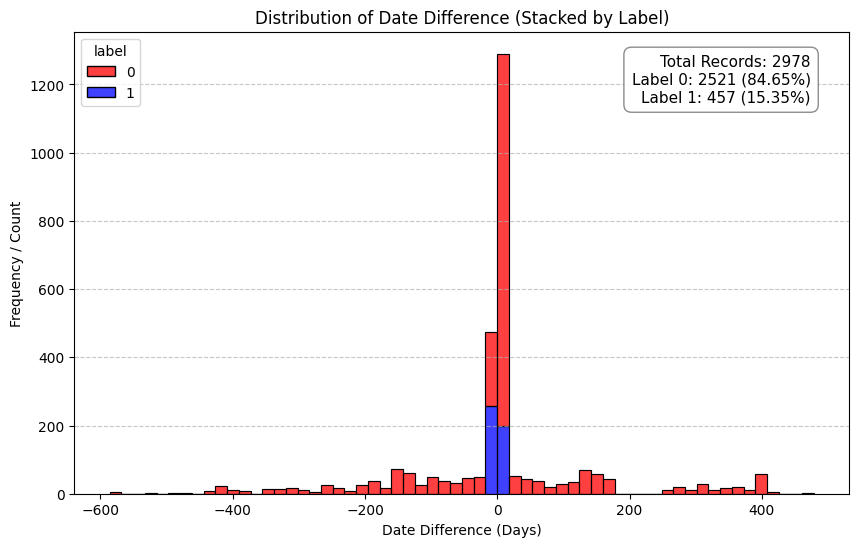

In [38]:
import seaborn as sns

plt.figure(figsize=(10, 6))

# sns.histplot(
#     data=training_data, 
#     x='date_diff_days', 
#     hue='label', 
#     multiple='dodge',
#     palette={0: 'blue', 1: 'red'},
#     bins=30,
#     edgecolor='black',
#     shrink=0.8
# )

# plt.title('Distribution of Date Difference (Side-by-Side by Label)')
# plt.xlabel('Date Difference (Days)')
# plt.ylabel('Frequency / Count')
# plt.grid(axis='y', linestyle='--', alpha=0.7)

# plt.show()

sns.histplot(
    data=training_data, 
    x='date_diff_days', 
    hue='label',
    multiple='stack',
    palette={1: 'blue', 0: 'red'},
    bins=60,
    edgecolor='black'
)

counts = training_data['label'].value_counts()
count_0 = counts.get(0, 0)
count_1 = counts.get(1, 0)
count_0_pct = count_0 / len(training_data)
count_1_pct = count_1 / len(training_data)
info_text = f"Total Records: {len(training_data)}\nLabel 0: {count_0} ({count_0_pct:.2%})\nLabel 1: {count_1} ({count_1_pct:.2%})"


plt.text(
    0.95, 0.95,
    info_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(
        boxstyle='round,pad=0.5', 
        facecolor='white', 
        edgecolor='gray', 
        alpha=0.9
    )
)

plt.title('Distribution of Date Difference (Stacked by Label)')
plt.xlabel('Date Difference (Days)')
plt.ylabel('Frequency / Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
# # Function to generate histograms for each group
# import os
# import time
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# def generate_group_histograms(df: pd.DataFrame, group_list: list, is_fp: bool = False, output_folder: str = "FP_Groups_Histograms"):
#     """
#     Iterates through a list of group tuples, generates a stacked histogram for each, 
#     and saves them as PNG files in a specified folder.
#     """
#     # 1. Create the output folder if it doesn't exist
#     os.makedirs(output_folder, exist_ok=True)
#     print(f"Saving plots to directory: ./{output_folder}/")

#     # 2. Iterate through the list of tuples
#     for group in group_list:
#         buyer, seller, product, shipto = group

#         safe_filename = f"{buyer}_{seller}_{product}_{shipto}.png"
#         file_path = os.path.join(output_folder, safe_filename)
        
#         if os.path.exists(file_path):
#             print(f"Skipping {safe_filename} - Graph already exists.")
#             continue
        
#         # Filter the data for the specific group
#         training_data = df[
#             (df['UDC_BUYERDUNS'] == buyer) & 
#             (df['UDC_SELLERDUNS'] == seller) & 
#             (df['UDC_DFC_PRODUCT'] == product) & 
#             (df['UDC_DFC_SHIPTO'] == shipto)
#         ].copy()

#         # Safety check: skip if the group has no data
#         if training_data.empty:
#             print(f"Skipping {group} - No data found.")
#             continue

#         # Calculate features
#         if not is_fp:
#             training_data['date_diff_days'] = (training_data['forecast_date'] - training_data['existing_date']).dt.days
#             training_data['qty_pct_change'] = (training_data['forecast_qty'] - training_data['existing_qty']) / training_data['existing_qty']
#         else:
#             training_data['date_diff_days'] = training_data['abs_date_diff_days']
#             training_data['label'] = training_data['actual']
#         # 3. Setup the plot
#         plt.figure(figsize=(10, 6))

#         sns.histplot(
#             data=training_data, 
#             x='date_diff_days', 
#             hue='label',
#             multiple='stack',
#             palette={1: 'blue', 0: 'red'},
#             bins=30,
#             edgecolor='black'
#         )

#         # 4. Calculate stats for the text box
#         counts = training_data['label'].value_counts()
#         count_0 = counts.get(0, 0)
#         count_1 = counts.get(1, 0)
#         total_records = len(training_data)
        
#         count_0_pct = count_0 / total_records if total_records > 0 else 0
#         count_1_pct = count_1 / total_records if total_records > 0 else 0
        
#         info_text = f"Total Records: {total_records}\nLabel 0: {count_0} ({count_0_pct:.2%})\nLabel 1: {count_1} ({count_1_pct:.2%})"

#         plt.text(
#             0.95, 0.95,
#             info_text,
#             transform=plt.gca().transAxes,
#             fontsize=11,
#             verticalalignment='top',
#             horizontalalignment='right',
#             bbox=dict(
#                 boxstyle='round,pad=0.5', 
#                 facecolor='white', 
#                 edgecolor='gray', 
#                 alpha=0.9
#             )
#         )

#         # 5. Add titles and labels
#         plt.title(f'Date Difference Distribution\nBuyer: {buyer} | Seller: {seller}\nProd: {product} | ShipTo: {shipto}')
#         plt.xlabel('Date Difference (Days)')
#         plt.ylabel('Frequency / Count')
#         plt.grid(axis='y', linestyle='--', alpha=0.7)

#         # 6. Save the plot to the folder
#         # Create a safe, unique filename using the group keys
#         safe_filename = f"{buyer}_{seller}_{product}_{shipto}.png"
#         file_path = os.path.join(output_folder, safe_filename)
        
#         # bbox_inches='tight' prevents the labels/titles from getting cut off in the saved image
#         plt.savefig(file_path, bbox_inches='tight')
        
#         # 7. CRITICAL: Close the figure to free up memory!
#         plt.close()
#         time.sleep(3)
        
#     print("All plots generated and saved successfully!")

In [93]:
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def generate_group_histograms(df: pd.DataFrame, group_list: list, is_fp: bool = False, output_folder: str = "FP_Groups_Histograms"):
    """
    Iterates through a list of group tuples, generates a stacked histogram (with a data table), 
    and saves them as PNG files in a specified folder. Skips existing graphs.
    """
    # 1. Create the output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    print(f"Saving plots to directory: ./{output_folder}/")

    # 2. Iterate through the list of tuples
    for group in group_list:
        buyer, seller, product, shipto = group

        # Define file path and check if it already exists
        safe_filename = f"{buyer}_{seller}_{product}_{shipto}.png"
        file_path = os.path.join(output_folder, safe_filename)
        
        if os.path.exists(file_path):
            print(f"Skipping {safe_filename} - Graph already exists.")
            continue
        
        # Filter the data for the specific group
        training_data = df[
            (df['UDC_BUYERDUNS'] == buyer) & 
            (df['UDC_SELLERDUNS'] == seller) & 
            (df['UDC_DFC_PRODUCT'] == product) & 
            (df['UDC_DFC_SHIPTO'] == shipto)
        ].copy()

        # Safety check: skip if the group has no data
        if training_data.empty:
            print(f"Skipping {group} - No data found.")
            continue

        # Calculate features based on the is_fp flag
        if not is_fp:
            training_data['date_diff_days'] = (training_data['forecast_date'] - training_data['existing_date']).dt.days
            training_data['qty_pct_change'] = (training_data['forecast_qty'] - training_data['existing_qty']) / training_data['existing_qty']
        else:
            training_data['date_diff_days'] = training_data['abs_date_diff_days']
            training_data['label'] = training_data['actual']

        # 3. Setup the 2-Column Plot (Left: Histogram, Right: Table)
        fig, (ax_plot, ax_table) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [2, 1]})

        # Separate data for plotting
        data_0 = training_data[training_data['label'] == 0]['date_diff_days'].dropna()
        data_1 = training_data[training_data['label'] == 1]['date_diff_days'].dropna()

        # Plot using Matplotlib's hist to easily capture bins and counts
        counts, bins, _ = ax_plot.hist(
            [data_0, data_1], 
            bins=15,               # Using 15 bins so the table fits comfortably
            stacked=True,
            color=['red', 'blue'],
            label=['Label 0', 'Label 1'],
            edgecolor='black'
        )

        # Force exact bin edges on the x-axis and rotate them
        ax_plot.set_xticks(bins)
        ax_plot.tick_params(axis='x', rotation=45)

        # 4. Calculate stats for the text box
        label_counts = training_data['label'].value_counts()
        count_0 = label_counts.get(0, 0)
        count_1 = label_counts.get(1, 0)
        total_records = len(training_data)
        
        count_0_pct = count_0 / total_records if total_records > 0 else 0
        count_1_pct = count_1 / total_records if total_records > 0 else 0
        
        info_text = f"Total Records: {total_records}\nLabel 0: {count_0} ({count_0_pct:.2%})\nLabel 1: {count_1} ({count_1_pct:.2%})"

        # Add text box to the plot axis (ax_plot)
        ax_plot.text(
            0.95, 0.95,
            info_text,
            transform=ax_plot.transAxes,
            fontsize=11,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
        )

        # Add titles and labels to the plot
        ax_plot.set_title(f'Date Difference Distribution\nBuyer: {buyer} | Seller: {seller}\nProd: {product} | ShipTo: {shipto}')
        ax_plot.set_xlabel('Date Difference (Days)')
        ax_plot.set_ylabel('Frequency / Count')
        ax_plot.grid(axis='y', linestyle='--', alpha=0.7)
        ax_plot.legend(loc='upper left')

        # 5. Build the Bin Counts Table on the right
        all_data = training_data['date_diff_days'].dropna()
        total_counts, _ = np.histogram(all_data, bins=bins)
        
        table_data = []
        for i in range(len(bins)-1):
            range_str = f"[{bins[i]:.1f} to {bins[i+1]:.1f})"
            table_data.append([range_str, int(total_counts[i])])

        ax_table.axis('off')
        ax_table.set_title('Bin Counts Table', pad=20, fontsize=14)

        table = ax_table.table(
            cellText=table_data,
            colLabels=['Bin Edges (Days)', 'Total Count'],
            loc='center',
            cellLoc='center'
        )
        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1, 1.8)

        # 6. Save the plot
        plt.tight_layout() # Ensures everything fits and labels aren't cut off
        fig.savefig(file_path, bbox_inches='tight')
        print(f"Saved: {safe_filename}")
        
        # 7. Close and Sleep
        plt.close(fig)
        time.sleep(3)
        
    print("All plots generated and saved successfully!")

In [83]:
training_data['qty_pct_change'].describe()

count    2978.000000
mean        7.345316
std        20.768178
min        -0.989984
25%        -0.227273
50%         0.000000
75%         0.294118
max        98.819068
Name: qty_pct_change, dtype: float64

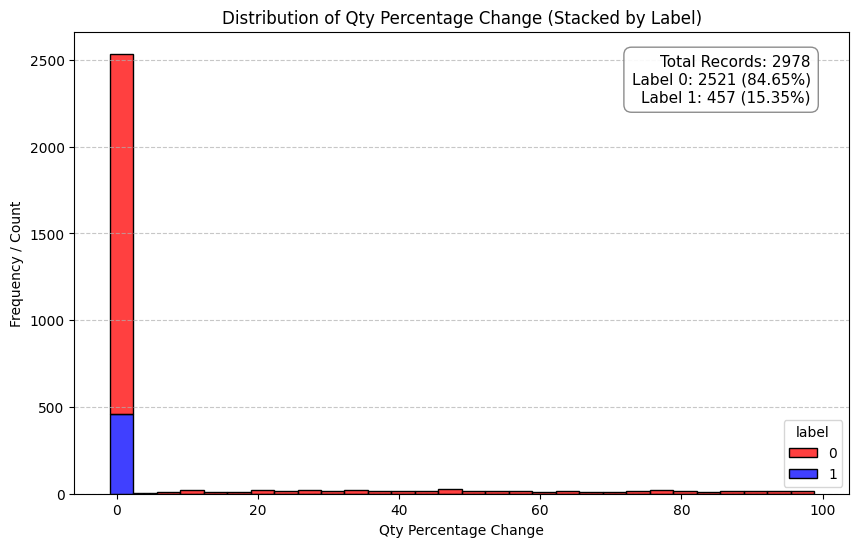

In [42]:
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(
    data=training_data, 
    x='qty_pct_change', 
    hue='label',
    multiple='stack',
    palette={1: 'blue', 0: 'red'},
    bins=30,
    edgecolor='black'
)

counts = training_data['label'].value_counts()
count_0 = counts.get(0, 0)
count_1 = counts.get(1, 0)
count_0_pct = count_0 / len(training_data)
count_1_pct = count_1 / len(training_data)
info_text = f"Total Records: {len(training_data)}\nLabel 0: {count_0} ({count_0_pct:.2%})\nLabel 1: {count_1} ({count_1_pct:.2%})"


plt.text(
    0.95, 0.95,
    info_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(
        boxstyle='round,pad=0.5', 
        facecolor='white', 
        edgecolor='gray', 
        alpha=0.9
    )
)

plt.title('Distribution of Qty Percentage Change (Stacked by Label)')
plt.xlabel('Qty Percentage Change')
plt.ylabel('Frequency / Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [43]:
# import pandas as pd

# # 1. Combine features and targets for both sets
# train_export = X_train.copy()
# train_export[TARGET] = y_train.values
# # train_export['data_split'] = 'train'  # Optional: helps Canvas identify rows

# test_export = X_test.copy()
# test_export[TARGET] = y_test.values
# # test_export['data_split'] = 'test'   # Optional

# # 2. Stack them vertically into one single DataFrame
# combined_dataset = pd.concat([train_export, test_export], axis=0)

# # 3. Define path and save
# combined_path = "D:\TenupProjects\elemica\canvas_full_dataset_new_03_03_2026.csv"
# combined_dataset.to_csv(combined_path, index=False)

# print(f"Combined dataset saved to {combined_path} ({len(combined_dataset)} rows)")

In [44]:
# import pandas as pd

# # 1. Combine features and targets for both sets
# group_train_export = X_train_group.copy()
# group_train_export[TARGET] = y_train_group.values
# # train_export['data_split'] = 'train'  # Optional: helps Canvas identify rows

# group_test_export = X_test_group.copy()
# group_test_export[TARGET] = y_test_group.values
# # test_export['data_split'] = 'test'   # Optional

# # 2. Stack them vertically into one single DataFrame
# group_combined_dataset = pd.concat([group_train_export, group_test_export], axis=0)

# # 3. Define path and save
# combined_path = "Logs\canvas_full_dataset_new_03_03_2026.csv"
# group_combined_dataset.to_csv(combined_path, index=False)

# print(f"Combined dataset saved to {combined_path} ({len(group_combined_dataset)} rows)")

In [45]:
# import shap
# import matplotlib.pyplot as plt

# print("\n--- SHAP Feature Importance ---")

# # Initialize JavaScript visualizations in the notebook
# shap.initjs()

# # Initialize the explainer using your trained model
# # (If you used Cell 1, you can swap 'model' for 'grid_model' here)
# explainer = shap.TreeExplainer(model)

# # Calculate SHAP values for the test set. 
# # We sample it to save computation time if your test set is massive.
# X_test_sample = X_test.sample(n=len(X_test), random_state=42)
# shap_values = explainer.shap_values(X_test_sample)

# # 1. Summary Plot (Beeswarm): Shows feature impact and direction
# plt.figure(figsize=(10, 8))
# plt.title("SHAP Beeswarm Plot")
# shap.summary_plot(shap_values, X_test_sample, plot_type="dot")
# plt.show()

# # 2. Bar Plot: Shows average absolute impact magnitude
# plt.figure(figsize=(10, 8))
# plt.title("SHAP Feature Importance (Mean Absolute Impact)")
# shap.summary_plot(shap_values, X_test_sample, plot_type="bar")
# plt.show()

In [46]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np

# print("\n--- Feature Correlation Matrix ---")

# # Filter out categorical string features to compute correlation only on numericals
# X_train_numeric = X_train.select_dtypes(include=[np.number])

# # Compute the correlation matrix
# corr_matrix = X_train_numeric.corr()

# # Set up the matplotlib figure
# plt.figure(figsize=(14, 12))

# # Generate a custom diverging colormap (Red/Blue)
# cmap = sns.diverging_palette(230, 20, as_cmap=True)

# # Draw the heatmap
# sns.heatmap(
#     corr_matrix, 
#     cmap=cmap, 
#     vmax=1.0, 
#     vmin=-1.0, 
#     center=0,
#     square=True, 
#     linewidths=.5, 
#     cbar_kws={"shrink": .7},
#     annot=False # Change to True if you want the exact decimals, but it can get cluttered
# )

# plt.title('Correlation Matrix of Numerical Features', fontsize=16)
# plt.tight_layout()
# plt.show()

In [47]:
# # CatBoost has a highly optimized, built-in .grid_search() method that plays perfectly with the Pool objects you already created. 
# # It's generally much faster than wrapping it in scikit-learn's GridSearchCV.

# print("\n--- Training CatBoost using Grid Search ---")

# # Initialize a fresh base model for tuning
# grid_model = CatBoostClassifier(
#     loss_function='Logloss',
#     eval_metric='AUC',
#     auto_class_weights='Balanced',
#     random_seed=42,
#     verbose=False # Keep console clean during grid search
# )

# # Define the hyperparameter grid you want to explore
# param_grid = {
#     'depth': [4, 6, 8],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'iterations': [500, 1000]
# }

# # Perform the grid search using your train_pool
# # plot=True will render a nice interactive UI right in your Jupyter Notebook
# grid_search_result = grid_model.grid_search(
#     param_grid,
#     X=train_pool,
#     cv=10,
#     partition_random_seed=42,
#     search_by_train_test_split=True,
#     plot=True 
# )

# print("\nBest parameters found:")
# print(grid_search_result['params'])

# # Note: After grid_search completes, grid_model is automatically 
# # refitted using the best parameters on the full train_pool.

In [48]:
# # Combine train features + target
# train_export = X_train.copy()
# train_export[TARGET] = y_train.values

# # Combine test features + target
# test_export = X_test.copy()
# test_export[TARGET] = y_test.values

# train_path = "D:/TenupProjects/elemica/train_dataset_canvas.csv"
# test_path  = "D:/TenupProjects/elemica/test_dataset_canvas.csv"

# train_export.to_csv(train_path, index=False)
# test_export.to_csv(test_path, index=False)

# print("Datasets saved successfully.")

In [49]:
from sklearn.metrics import f1_score
print("\n--- Evaluation ---")
y_pred_proba = model.predict_proba(test_pool)[:, 1]
y_pred = model.predict(test_pool)

auc = roc_auc_score(y_test, y_pred_proba)
f1_score = f1_score(y_test, y_pred)
print(f"Test AUC: {auc:.4f}")
print(f"Test F1: {f1_score:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

# Targeted slice check: date match & qty extreme (veto scenario)
global_qty_p95 = df_train_pairs[df_train_pairs[TARGET] == 1]['abs_qty_pct_change'].quantile(0.95)
global_qty_p99 = df_train_pairs[df_train_pairs[TARGET] == 1]['abs_qty_pct_change'].quantile(0.99)
global_qty_T = max(global_qty_p99, 2 * global_qty_p95)

slice_mask = (df_test_final['abs_date_diff_days'] <= 1) & (df_test_final['abs_qty_pct_change'] > global_qty_T)
if slice_mask.any():
    slice_scores = y_pred_proba[slice_mask.values]
    slice_labels = y_test[slice_mask.values]
    print(f"\nSlice (date_match<=1 day & qty_pct>{global_qty_T:.2f}): n={slice_mask.sum()}")
    print(f"  mean_pred={slice_scores.mean():.4f} | median_pred={np.median(slice_scores):.4f}")
    print(f"  positives={slice_labels.sum()} | negatives={(slice_mask.sum()-slice_labels.sum())}")
else:
    print("\nSlice (date_match<=1 day & qty extreme): none in test set.")

feature_importance = model.get_feature_importance(train_pool, prettified=True)
print("\nTop Feature Importances:")
print(feature_importance.head(50).to_string())


--- Evaluation ---
Test AUC: 0.9590
Test F1: 0.7182

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     61887
           1       0.58      0.93      0.72     11670

    accuracy                           0.88     73557
   macro avg       0.79      0.90      0.82     73557
weighted avg       0.92      0.88      0.89     73557


Slice (date_match<=1 day & qty_pct>2.00): n=669
  mean_pred=0.1612 | median_pred=0.0141
  positives=91 | negatives=578

Top Feature Importances:
                   Feature Id  Importances
0              max_veto_score    21.538207
1           combined_nearness    14.159065
2           abs_log_qty_ratio     7.262885
3             zscore_qty_diff     6.652505
4                   qty_ratio     4.345326
5             date_veto_score     3.819880
6          abs_date_diff_days     3.715890
7                qty_diff_log     3.203420
8    dev_abs_date_diff_vs_p95     3.024654
9               date

In [50]:
from sklearn.metrics import f1_score
print("\n--- Evaluation ---")
y_pred_proba_group = group_model.predict_proba(test_pool_group)[:, 1]
y_pred_group = group_model.predict(test_pool_group)

auc_group = roc_auc_score(y_test_group, y_pred_proba_group)
f1_score_group = f1_score(y_test_group, y_pred_group)
print(f"Group - Test AUC: {auc_group:.4f}")
print(f"Group - Test F1: {f1_score_group:.4f}")
print(f"\nGroup - Classification Report:\n{classification_report(y_test_group, y_pred_group)}")

# Targeted slice check: date match & qty extreme (veto scenario)
global_qty_p95_group = group_df_train_pairs[group_df_train_pairs[TARGET] == 1]['abs_qty_pct_change'].quantile(0.95)
global_qty_p99_group = group_df_train_pairs[group_df_train_pairs[TARGET] == 1]['abs_qty_pct_change'].quantile(0.99)
global_qty_T_group = max(global_qty_p99_group, 2 * global_qty_p95_group)

slice_mask_group = (group_df_test_final['abs_date_diff_days'] <= 1) & (group_df_test_final['abs_qty_pct_change'] > global_qty_T_group)
if slice_mask_group.any():
    slice_scores_group = y_pred_proba_group[slice_mask_group.values]
    slice_labels_group = y_test_group[slice_mask_group.values]
    print(f"\nSlice (date_match<=1 day & qty_pct>{global_qty_T_group:.2f}): n={slice_mask_group.sum()}")
    print(f"  mean_pred={slice_scores_group.mean():.4f} | median_pred={np.median(slice_scores_group):.4f}")
    print(f"  positives={slice_labels_group.sum()} | negatives={(slice_mask_group.sum()-slice_labels_group.sum())}")
else:
    print("\nSlice (date_match<=1 day & qty extreme): none in test set.")

group_feature_importance = group_model.get_feature_importance(train_pool_group, prettified=True)
print("\nTop Feature Importances:")
print(group_feature_importance.head(50).to_string())


--- Evaluation ---
Group - Test AUC: 0.9693
Group - Test F1: 0.7470

Group - Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     61887
           1       0.61      0.96      0.75     11670

    accuracy                           0.90     73557
   macro avg       0.80      0.92      0.84     73557
weighted avg       0.93      0.90      0.91     73557


Slice (date_match<=1 day & qty_pct>2.00): n=640
  mean_pred=0.1310 | median_pred=0.0091
  positives=80 | negatives=560

Top Feature Importances:
                   Feature Id  Importances
0             date_veto_score    11.589883
1           abs_log_qty_ratio     8.728596
2              max_veto_score     7.064341
3    date_veto_x_qty_nearness     6.817254
4          abs_date_diff_days     5.063432
5          abs_qty_pct_change     4.886906
6                qty_nearness     4.467345
7                   qty_ratio     4.369321
8             zscore_qty_diff     4.270

In [51]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.01)

best_f1 = 0
best_threshold = 0

for t in thresholds:
    preds = (y_pred_proba >= t).astype(int)
    f1 = f1_score(y_test, preds)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

Best Threshold: 0.8199999999999996
Best F1: 0.7507156582094819


In [52]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.01)

best_f1_group = 0
best_threshold_group = 0

for t in thresholds:
    preds_group = (y_pred_proba_group >= t).astype(int)
    f1_group = f1_score(y_test_group, preds_group)
    
    if f1_group > best_f1:
        best_f1_group = f1_group
        best_threshold_group = t

print("Group - Best Threshold:", best_threshold_group)
print("Group - Best F1:", best_f1_group)

Group - Best Threshold: 0.8699999999999996
Group - Best F1: 0.7560128505687245


In [53]:
# from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# def tune_threshold_for_precision(y_true, y_probs, min_precision=0.88):
#     best_t = 0.5
#     best_f1 = 0
#     for t in np.arange(0.1, 0.99, 0.01):
#         preds = (y_probs >= t).astype(int)
#         p = precision_score(y_true, preds, zero_division=0)
#         f1 = f1_score(y_test_group, preds_group)
#         if p >= min_precision and f1 > best_f1:
#             best_f1 = f1
#             best_t = t
#     return best_t, best_f1

In [54]:
# best_t, best_f1 = tune_threshold_for_precision(y_test_group, y_pred_proba_group)

# print(f"@Min precision = 0.99 --> Best Threshold: {best_t:.4f} | Best F1: {best_f1:.4f}")

In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()  # unpack

print("\n--- Confusion Matrix ---")
print(f"True Positives  (TP): {tp}")
print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")

# Optional: also print rates
tpr = tp / (tp + fn)  # Recall / Sensitivity
tnr = tn / (tn + fp)  # Specificity
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print("\n--- Rates ---")
print(f"True Positive Rate (Recall/Sensitivity): {tpr:.4f}")
print(f"True Negative Rate (Specificity):        {tnr:.4f}")
print(f"False Positive Rate:                     {fpr:.4f}")
print(f"False Negative Rate:                     {fnr:.4f}")


--- Confusion Matrix ---
True Positives  (TP): 10854
True Negatives  (TN): 54187
False Positives (FP): 7700
False Negatives (FN): 816

--- Rates ---
True Positive Rate (Recall/Sensitivity): 0.9301
True Negative Rate (Specificity):        0.8756
False Positive Rate:                     0.1244
False Negative Rate:                     0.0699


In [56]:
from sklearn.metrics import confusion_matrix

gp_cm = confusion_matrix(y_test_group, y_pred_group)
tn, fp, fn, tp = gp_cm.ravel()

print("\n--- Confusion Matrix ---")
print(f"True Positives  (TP): {tp}")
print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")

# Optional: also print rates
tpr = tp / (tp + fn)  # Recall / Sensitivity
tnr = tn / (tn + fp)  # Specificity
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print("\n--- Rates ---")
print(f"True Positive Rate (Recall/Sensitivity): {tpr:.4f}")
print(f"True Negative Rate (Specificity):        {tnr:.4f}")
print(f"False Positive Rate:                     {fpr:.4f}")
print(f"False Negative Rate:                     {fnr:.4f}")


--- Confusion Matrix ---
True Positives  (TP): 11177
True Negatives  (TN): 54808
False Positives (FP): 7079
False Negatives (FN): 493

--- Rates ---
True Positive Rate (Recall/Sensitivity): 0.9578
True Negative Rate (Specificity):        0.8856
False Positive Rate:                     0.1144
False Negative Rate:                     0.0422


In [57]:
# from sklearn.metrics import confusion_matrix

# CUSTOM_THRESHOLD = 0.869

# y_pred_probabilities = model.predict_proba(X_test_group)[:, 1]
# y_pred_custom = (y_pred_probabilities >= CUSTOM_THRESHOLD).astype(int)

# cm_custom = confusion_matrix(y_test_group, y_pred_custom)
# tn, fp, fn, tp = cm_custom.ravel()

# print(f"--- Confusion Matrix at Threshold {CUSTOM_THRESHOLD} ---")
# print(f"True Positives  (TP): {tp}")
# print(f"True Negatives  (TN): {tn}")
# print(f"False Positives (FP): {fp}")
# print(f"False Negatives (FN): {fn}")

### FP Analysis

In [58]:
print(y_test_group.shape)
print(y_test_group.value_counts())
print(y_pred_group.shape)
print(pd.DataFrame(y_pred_group).value_counts())

(73557,)
label
0    61887
1    11670
Name: count, dtype: int64
(73557,)
0
0    55301
1    18256
Name: count, dtype: int64


In [59]:
# group_y_pred = (y_pred_proba_group >= 0.5).astype(int)

analysis_df = X_test_group.copy()
analysis_df['actual'] = y_test_group
analysis_df['predicted'] = y_pred_group
analysis_df['probability'] = y_pred_proba_group

fp_df = analysis_df[(analysis_df['actual'] == 0) & (analysis_df['predicted'] == 1)]
tn_df = analysis_df[(analysis_df['actual'] == 0) & (analysis_df['predicted'] == 0)]
tp_df = analysis_df[(analysis_df['actual'] == 1) & (analysis_df['predicted'] == 1)]

print(f"Isolated {len(fp_df)} False Positives for analysis.")
print(f"Isolated {len(tn_df)} True Negative for analysis.")
print(f"Isolated {len(tp_df)} True Positives for analysis.")

Isolated 7079 False Positives for analysis.
Isolated 54808 True Negative for analysis.
Isolated 11177 True Positives for analysis.


In [60]:
fp_df.head()

,UDC_BUYERDUNS,UDC_SELLERDUNS,UDC_DFC_PRODUCT,UDC_DFC_SHIPTO,abs_date_diff_days,qty_ratio,abs_qty_pct_change,date_diff_log,qty_diff_log,abs_log_qty_ratio,...,qty_direction_likelihood,date_direction_likelihood,qty_nearness,date_nearness,combined_nearness,qty_veto_x_date_nearness,date_veto_x_qty_nearness,actual,predicted,probability
10,3153699342000,480150752,0452968-00,020;22950,5,1.000000,0.000000,-1.791759,0.000000,7.936509e-10,...,1.0000,0.3545,1.000000,0.489542,0.489542,0.000000,0.093633,0,1,0.919441
25,0580,480000926,0442203681,0580,7,0.500000,0.500000,-2.079442,-3.931826,6.931472e-01,...,0.6522,0.8454,0.135335,0.367879,0.049787,0.183940,0.011041,0,1,0.887245
39,315000125,316097161,5000000283,5067-7RBC5,0,0.500000,0.500000,0.000000,-5.666427,6.931472e-01,...,0.7405,1.0000,0.135335,1.000000,0.135335,0.499999,0.000000,0,1,0.978831
48,001316827,001307032,000000000010090204,1727,4,0.950501,0.049499,1.609438,-8.294180,5.076608e-02,...,0.9664,0.1477,0.820373,0.564718,0.463280,0.059716,0.410186,0,1,0.801314
49,001316827,001307032,000000000098894422,1727,1,0.519212,0.480788,-0.693147,-9.186150,6.554433e-01,...,0.9646,0.6944,0.146145,0.866878,0.126690,1.683972,0.009743,0,1,0.612168


In [61]:
fp_df[fp_df['abs_qty_pct_change'] == 0].head()

,UDC_BUYERDUNS,UDC_SELLERDUNS,UDC_DFC_PRODUCT,UDC_DFC_SHIPTO,abs_date_diff_days,qty_ratio,abs_qty_pct_change,date_diff_log,qty_diff_log,abs_log_qty_ratio,...,qty_direction_likelihood,date_direction_likelihood,qty_nearness,date_nearness,combined_nearness,qty_veto_x_date_nearness,date_veto_x_qty_nearness,actual,predicted,probability
10,3153699342000,480150752,0452968-00,020;22950,5,1.0,0.0,-1.791759,0.0,7.936509e-10,...,1.0,0.3545,1.0,0.489542,0.489542,0.0,0.093633,0,1,0.919441
188,O0013000023HELLA-KG-EDIP,316097161,616.027-18M,1014,9,1.0,0.0,2.302585,0.0,5.555555e-09,...,1.0,0.4190,1.0,0.276453,0.276453,0.0,0.112500,0,1,0.894223
189,O0013000023HELLA-KG-EDIP,316097161,616.027-18M,1014,28,1.0,0.0,3.367296,0.0,5.555555e-09,...,1.0,0.4190,1.0,0.018316,0.018316,0.0,0.350000,0,1,0.837463
192,O0013000023HELLA-KG-EDIP,316097161,616.027-18M,1014,35,1.0,0.0,3.583519,0.0,5.555555e-09,...,1.0,0.4190,1.0,0.006738,0.006738,0.0,0.437500,0,1,0.834956
208,3153699342000,480150752,0456197-00,152;51H10,2,1.0,0.0,1.098612,0.0,5.555556e-10,...,1.0,0.5000,1.0,0.751477,0.751477,0.0,0.048780,0,1,0.884862


In [62]:
print(fp_df['abs_qty_pct_change'].describe())

print(f"\n Count of abs_qty_pct_change = 0: {fp_df[fp_df['abs_qty_pct_change'] == 0].shape[0]} ({fp_df[fp_df['abs_qty_pct_change'] == 0].shape[0] / fp_df.shape[0] * 100}%)")
print(f"\n Count of abs_date_diff_days = 0: {fp_df[fp_df['abs_date_diff_days'] == 0].shape[0]} ({fp_df[fp_df['abs_date_diff_days'] == 0].shape[0] / fp_df.shape[0] * 100}%)")
print(f"\n Count of abs_qty_pct_change = 0 and abs_date_diff_days = 0: {fp_df[(fp_df['abs_qty_pct_change'] == 0) & (fp_df['abs_date_diff_days'] == 0)].shape[0]} ({fp_df[(fp_df['abs_qty_pct_change'] == 0) & (fp_df['abs_date_diff_days'] == 0)].shape[0] / fp_df.shape[0] * 100}%)")

print(f"\n abs_date_diff_days mean(for abs_qty_pct_change = 0): {fp_df[fp_df['abs_qty_pct_change'] == 0]['abs_date_diff_days'].mean()}")
print(f"\n abs_qty_pct_change mean(for abs_qty_pct_change = 0): {fp_df[fp_df['abs_date_diff_days'] == 0]['abs_qty_pct_change'].mean()}")

count    7079.000000
mean        0.437452
std         0.939594
min         0.000000
25%         0.000000
50%         0.100000
75%         0.500000
max        20.000000
Name: abs_qty_pct_change, dtype: float64

 Count of abs_qty_pct_change = 0: 3084 (43.56547534962566%)

 Count of abs_date_diff_days = 0: 495 (6.992513066817348%)

 Count of abs_qty_pct_change = 0 and abs_date_diff_days = 0: 0 (0.0%)

 abs_date_diff_days mean(for abs_qty_pct_change = 0): 14.81290531776913

 abs_qty_pct_change mean(for abs_qty_pct_change = 0): 0.6507441589305261


In [63]:
# neg = fp_df[(fp_df['UDC_BUYERDUNS'] == '000X0FYCSA614') & (fp_df['UDC_SELLERDUNS'] == '480000926') & (fp_df['UDC_DFC_PRODUCT'] == '10000847') & (fp_df['UDC_DFC_SHIPTO'] == '6140')].copy()
neg = fp_df.copy()

print(f"False Positives for given group: {len}")
DATE_CLOSE_DAYS = 7
QTY_FAR_PCT = 0.2

print("  Qty (% change):  mean = {:.4f}  |  p95 = {:.4f}  |  p99 = {:.4f}".format(neg['abs_qty_pct_change'].mean(), neg['abs_qty_pct_change'].quantile(0.95), neg['abs_qty_pct_change'].quantile(0.99)))
print("  Date (days):     mean = {:.1f}  |  p95 = {:.1f}  |  p99 = {:.1f}".format(neg['abs_date_diff_days'].mean(), neg['abs_date_diff_days'].quantile(0.95), neg['abs_date_diff_days'].quantile(0.99)))

type_a_like = (neg['abs_date_diff_days'] <= DATE_CLOSE_DAYS) & (neg['abs_qty_pct_change'] > QTY_FAR_PCT)
type_b_like = (neg['abs_qty_pct_change'] <= QTY_FAR_PCT) & (neg['abs_date_diff_days'] > DATE_CLOSE_DAYS)
exact_date_extreme = (neg['abs_date_diff_days'] <= 1) & (neg['abs_qty_pct_change'] > QTY_FAR_PCT)

print(f"\n=== Thresholds: date_close<={DATE_CLOSE_DAYS}d, qty_far>{QTY_FAR_PCT*100}%) ===")
print("  Type A–like (date-close, qty-far):  {:5d}  ({:.1f}%)".format(type_a_like.sum(), 100*type_a_like.mean()))
print("  Type B–like (qty-close, date-far):  {:5d}  ({:.1f}%)".format(type_b_like.sum(), 100*type_b_like.mean()))
print("  Exact-date qty-extreme (date<=1d):  {:5d}  ({:.1f}%)".format(exact_date_extreme.sum(), 100*exact_date_extreme.mean()))

print("\n=== Counts ===")
print("  Negatives: {}".format(len(neg)))
print("  Negatives with exact date (|date_diff_days|<= 15): {} ({:.1f}%)".format((neg['abs_date_diff_days'] <= 15).sum(), 100*(neg['abs_date_diff_days'] <= 15).mean()))
print(neg[(neg['abs_date_diff_days'] <= 15) == True]['abs_qty_pct_change'].max())
print("  Negatives with |date_diff_days|<= 15: {} ({:.1f}%)".format((neg['abs_date_diff_days'] <= 15).sum(), 100*(neg['abs_date_diff_days'] <= 15).mean()))

False Positives for given group: <built-in function len>
  Qty (% change):  mean = 0.4375  |  p95 = 2.0000  |  p99 = 4.0000
  Date (days):     mean = 15.3  |  p95 = 56.0  |  p99 = 98.0

=== Thresholds: date_close<=7d, qty_far>20.0%) ===
  Type A–like (date-close, qty-far):   1557  (22.0%)
  Type B–like (qty-close, date-far):   1730  (24.4%)
  Exact-date qty-extreme (date<=1d):    622  (8.8%)

=== Counts ===
  Negatives: 7079
  Negatives with exact date (|date_diff_days|<= 15): 5082 (71.8%)
13.999999986
  Negatives with |date_diff_days|<= 15: 5082 (71.8%)


In [64]:
print("Count of abs_qty_pct_change = 0: {}".format(neg[(neg['abs_qty_pct_change'] == 0)].shape[0]))
print("Count of abs_date_diff_days = 0: {}".format(neg[(neg['abs_date_diff_days'] == 0)].shape[0]))

print("\nabs_date_diff_days info (when abs_qty_pct_change = 0): {}".format(neg[neg['abs_qty_pct_change'] == 0]['abs_date_diff_days'].describe()))
print("\nabs_qty_pct_change info (when abs_date_diff_days = 0): {}".format(neg[neg['abs_date_diff_days'] == 0]['abs_qty_pct_change'].describe()))

Count of abs_qty_pct_change = 0: 3084
Count of abs_date_diff_days = 0: 495

abs_date_diff_days info (when abs_qty_pct_change = 0): count    3084.000000
mean       14.812905
std        17.766579
min         1.000000
25%         4.000000
50%         7.000000
75%        19.000000
max       154.000000
Name: abs_date_diff_days, dtype: float64

abs_qty_pct_change info (when abs_date_diff_days = 0): count    495.000000
mean       0.650744
std        0.653535
min        0.000005
25%        0.239194
50%        0.500000
75%        0.800000
max        4.000000
Name: abs_qty_pct_change, dtype: float64


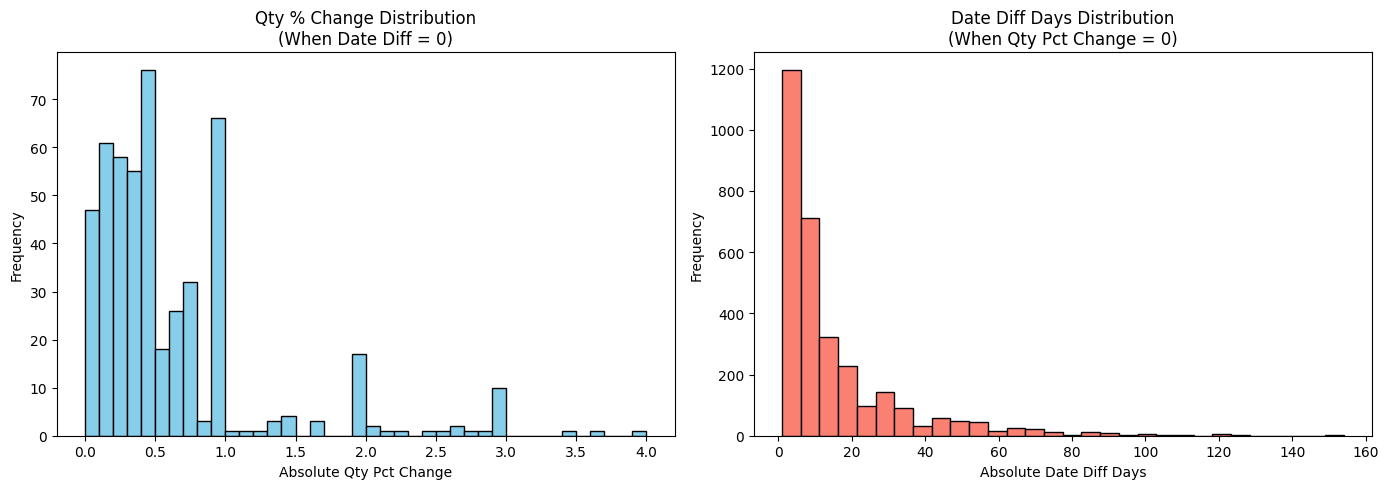

In [65]:
data_qty = neg[neg['abs_date_diff_days'] == 0]['abs_qty_pct_change']
data_date = neg[neg['abs_qty_pct_change'] == 0]['abs_date_diff_days']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts1, bins1, patches1 = axes[0].hist(data_qty, bins=40, color='skyblue', edgecolor='black')
axes[0].set_title('Qty % Change Distribution\n(When Date Diff = 0)')
axes[0].set_xlabel('Absolute Qty Pct Change')
axes[0].set_ylabel('Frequency')

counts2, bins2, patches2 = axes[1].hist(data_date, bins=30, color='salmon', edgecolor='black')
axes[1].set_title('Date Diff Days Distribution\n(When Qty Pct Change = 0)')
axes[1].set_xlabel('Absolute Date Diff Days')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

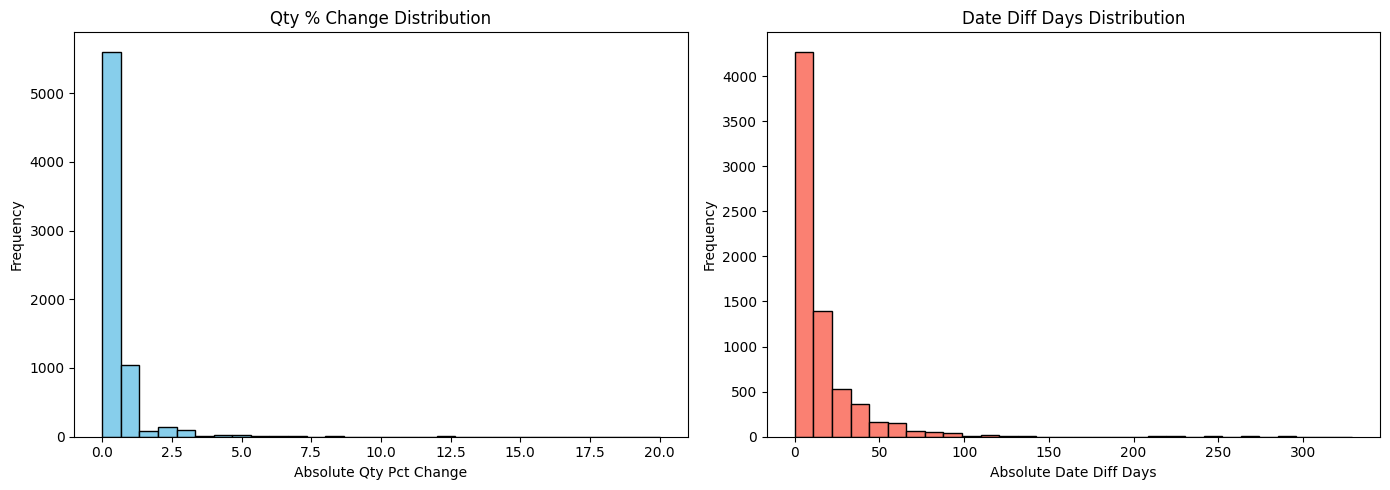

In [66]:
data_qty = neg['abs_qty_pct_change']
data_date = neg['abs_date_diff_days']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts1, bins1, patches1 = axes[0].hist(data_qty, bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Qty % Change Distribution')
axes[0].set_xlabel('Absolute Qty Pct Change')
axes[0].set_ylabel('Frequency')

counts2, bins2, patches2 = axes[1].hist(data_date, bins=30, color='salmon', edgecolor='black')
axes[1].set_title('Date Diff Days Distribution')
axes[1].set_xlabel('Absolute Date Diff Days')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [67]:
tn_df[['UDC_BUYERDUNS', 'UDC_SELLERDUNS', 'UDC_DFC_PRODUCT', 'UDC_DFC_SHIPTO']].head()

,UDC_BUYERDUNS,UDC_SELLERDUNS,UDC_DFC_PRODUCT,UDC_DFC_SHIPTO
0,811313923,810007658,42568100852041-00,0008
1,811313923,810007658,42568100852041-00,0008
2,811313923,810007658,42568100852041-00,0008
3,811313923,810007658,42568100852041-00,0008
4,811313923,810007658,42568100852041-00,0008


In [68]:
print(tp_df['abs_qty_pct_change'].describe())
print("\n abs_qty_pct_change=0 in TP : {}".format(tp_df[(tp_df['abs_qty_pct_change'] == 0)].shape[0]))
print("\n Info of abs_date_diff_days when abs_qty_pct_change=0 in TP : \n{}".format(tp_df[(tp_df['abs_qty_pct_change'] == 0)]['abs_date_diff_days'].describe()))

count    11177.000000
mean         5.328645
std        322.035316
min          0.000000
25%          0.000000
50%          0.005848
75%          0.333333
max      23998.976001
Name: abs_qty_pct_change, dtype: float64

 abs_qty_pct_change=0 in TP : 5267

 Info of abs_date_diff_days when abs_qty_pct_change=0 in TP : 
count    5267.000000
mean        9.665654
std        15.274562
min         1.000000
25%         2.000000
50%         5.000000
75%         9.000000
max       201.000000
Name: abs_date_diff_days, dtype: float64


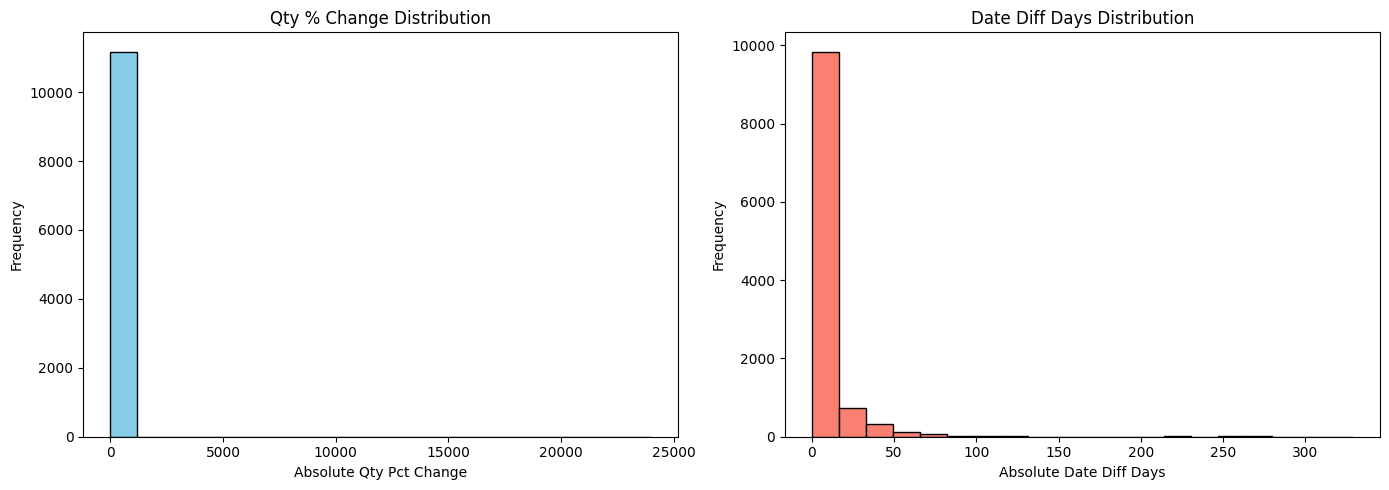

In [69]:
data_qty = tp_df['abs_qty_pct_change']
data_date = tp_df['abs_date_diff_days']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts1, bins1, patches1 = axes[0].hist(data_qty, bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Qty % Change Distribution')
axes[0].set_xlabel('Absolute Qty Pct Change')
axes[0].set_ylabel('Frequency')

counts2, bins2, patches2 = axes[1].hist(data_date, bins=20, color='salmon', edgecolor='black')
axes[1].set_title('Date Diff Days Distribution')
axes[1].set_xlabel('Absolute Date Diff Days')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [70]:
tn_df['abs_qty_pct_change'].describe()

count     54808.000000
mean       1111.786912
std       14594.560537
min           0.000000
25%           0.041667
50%           0.500000
75%           0.800000
max      359998.640001
Name: abs_qty_pct_change, dtype: float64

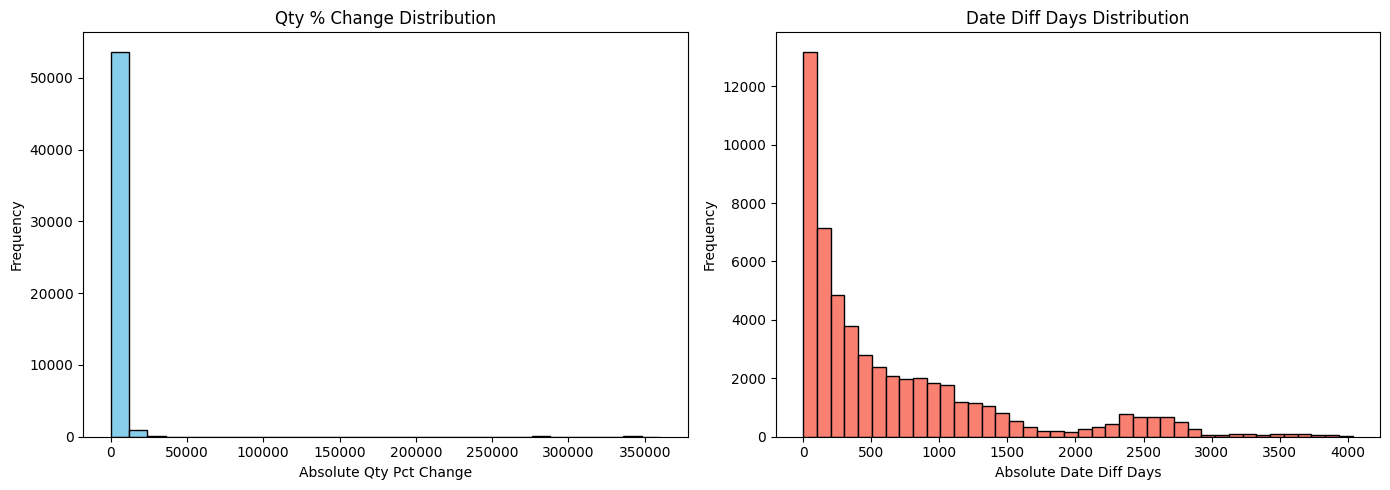

In [71]:
data_qty = tn_df['abs_qty_pct_change']
data_date = tn_df['abs_date_diff_days']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts1, bins1, patches1 = axes[0].hist(data_qty, bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Qty % Change Distribution')
axes[0].set_xlabel('Absolute Qty Pct Change')
axes[0].set_ylabel('Frequency')

counts2, bins2, patches2 = axes[1].hist(data_date, bins=40, color='salmon', edgecolor='black')
axes[1].set_title('Date Diff Days Distribution')
axes[1].set_xlabel('Absolute Date Diff Days')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [72]:
# Finding the Top frequent groups which has the most FPs
# Negative_Groups_Data
grouped_series = neg.groupby(
    ['UDC_BUYERDUNS', 'UDC_SELLERDUNS', 'UDC_DFC_PRODUCT', 'UDC_DFC_SHIPTO']
).size()

df_strict_2col = pd.DataFrame({
    'group_data': grouped_series.index.to_list(),
    'record_count': grouped_series.values
})

df_strict_2col_order = df_strict_2col.sort_values(by='record_count', ascending=False)
group_with_more_than_50_records = []
for ids, count in zip(df_strict_2col_order['group_data'], df_strict_2col_order['record_count']):
    if count > 170:
        group_with_more_than_50_records.append(ids)

print(len(group_with_more_than_50_records))
df_strict_2col_order.head(10)

print(group_with_more_than_50_records)
negative_groups_list = df_strict_2col_order['group_data'].to_list()


5
[('001316827', '001307032', '000000000090760543', '1731'), ('001316827', '001307032', '000000000090304003', '1731'), ('318346418', '316097161', '000000005200930000', '25013764-NONCONSIGNMENT'), ('370188203', '316097161', ' ABP G00 031', '21B'), ('MANNFIL', '897281309', '1912101199', '898175252')]


In [ ]:
generate_group_histograms(df=group_df_train_final, group_list = negative_groups_list, is_fp=False, output_folder="FB_Negative_Groups_Histograms_With_Bin_Table")

In [104]:
# Analysis of the group: 001316827_001307032_000000000090760543_1731 
# Data: group_df_train_final

g = group_df_train_final[(group_df_train_final['UDC_BUYERDUNS'] == '001316827') & (group_df_train_final['UDC_SELLERDUNS'] == '001307032') & (group_df_train_final['UDC_DFC_PRODUCT'] == '000000000090760543') & (group_df_train_final['UDC_DFC_SHIPTO'] == '1731')].copy()
print("Group Shape: {}".format(g.shape))
print("Group Label Distribution: {}".format(g['label'].value_counts()))

g['date_diff_days'] = (g['forecast_date'] - g['existing_date']).dt.days

filtered_g = g[(g['date_diff_days'] <= 53) & (g['date_diff_days'] >= -18) & (g['label'] == 0)].copy()
print("Filtered Group Shape: {}".format(filtered_g.shape))

eps = 1e-6
qty_diff_abs = filtered_g['forecast_qty'] / (filtered_g['existing_qty'] + eps).abs()
filtered_g['abs_qty_pct_change'] = qty_diff_abs / (filtered_g['existing_qty'].abs() + eps)

pd.set_option('display.float_format', lambda x: '%.6f' % x)
print(filtered_g['abs_qty_pct_change'].describe())

Group Shape: (2978, 50)
Group Label Distribution: label
0    2521
1     457
Name: count, dtype: int64
Filtered Group Shape: (1404, 51)
count   1404.000000
mean       0.000974
std        0.001676
min        0.000000
25%        0.000002
50%        0.000051
75%        0.001492
max        0.007099
Name: abs_qty_pct_change, dtype: float64


In [79]:
df_strict_2col_order[(df_strict_2col_order['group_data'] == ('054481205','001060615','693YL S1650', '00283728'))]

,group_data,record_count
36,"(054481205, 001060615, 693YL S1650, 00283728)",2


In [74]:
fp_df.head()

,UDC_BUYERDUNS,UDC_SELLERDUNS,UDC_DFC_PRODUCT,UDC_DFC_SHIPTO,abs_date_diff_days,qty_ratio,abs_qty_pct_change,date_diff_log,qty_diff_log,abs_log_qty_ratio,...,qty_direction_likelihood,date_direction_likelihood,qty_nearness,date_nearness,combined_nearness,qty_veto_x_date_nearness,date_veto_x_qty_nearness,actual,predicted,probability
10,3153699342000,480150752,0452968-00,020;22950,5,1.000000,0.000000,-1.791759,0.000000,7.936509e-10,...,1.0000,0.3545,1.000000,0.489542,0.489542,0.000000,0.093633,0,1,0.919441
25,0580,480000926,0442203681,0580,7,0.500000,0.500000,-2.079442,-3.931826,6.931472e-01,...,0.6522,0.8454,0.135335,0.367879,0.049787,0.183940,0.011041,0,1,0.887245
39,315000125,316097161,5000000283,5067-7RBC5,0,0.500000,0.500000,0.000000,-5.666427,6.931472e-01,...,0.7405,1.0000,0.135335,1.000000,0.135335,0.499999,0.000000,0,1,0.978831
48,001316827,001307032,000000000010090204,1727,4,0.950501,0.049499,1.609438,-8.294180,5.076608e-02,...,0.9664,0.1477,0.820373,0.564718,0.463280,0.059716,0.410186,0,1,0.801314
49,001316827,001307032,000000000098894422,1727,1,0.519212,0.480788,-0.693147,-9.186150,6.554433e-01,...,0.9646,0.6944,0.146145,0.866878,0.126690,1.683972,0.009743,0,1,0.612168


In [78]:
# FP_Data_Date_Diff_Histogram
generate_group_histograms(df=fp_df, group_list = negative_groups_list, is_fp=True, output_folder="FP_Data_Date_Diff_Histogram")


Saving plots to directory: ./FP_Data_Date_Diff_Histogram/
All plots generated and saved successfully!


In [89]:
numeric_cols = fp_df.select_dtypes(include=np.number).columns.tolist()
print(numeric_cols)
print(len(numeric_cols))
print(fp_df.shape)
fp_df.head()

['abs_date_diff_days', 'qty_ratio', 'abs_qty_pct_change', 'date_diff_log', 'qty_diff_log', 'abs_log_qty_ratio', 'kb_hist_update_rate', 'kb_date_diff_cv', 'kb_qty_diff_cv', 'kb_frac_postpone', 'kb_frac_qty_increase', 'zscore_date_diff', 'zscore_qty_diff', 'dev_abs_date_diff_vs_p95', 'dev_abs_qty_pct_vs_p95', 'qty_veto_score', 'date_veto_score', 'max_veto_score', 'qty_direction_likelihood', 'date_direction_likelihood', 'qty_nearness', 'date_nearness', 'combined_nearness', 'qty_veto_x_date_nearness', 'date_veto_x_qty_nearness', 'actual', 'predicted', 'probability']
28
(7079, 32)


,UDC_BUYERDUNS,UDC_SELLERDUNS,UDC_DFC_PRODUCT,UDC_DFC_SHIPTO,abs_date_diff_days,qty_ratio,abs_qty_pct_change,date_diff_log,qty_diff_log,abs_log_qty_ratio,...,qty_direction_likelihood,date_direction_likelihood,qty_nearness,date_nearness,combined_nearness,qty_veto_x_date_nearness,date_veto_x_qty_nearness,actual,predicted,probability
10,3153699342000,480150752,0452968-00,020;22950,5,1.000000,0.000000,-1.791759,0.000000,7.936509e-10,...,1.0000,0.3545,1.000000,0.489542,0.489542,0.000000,0.093633,0,1,0.919441
25,0580,480000926,0442203681,0580,7,0.500000,0.500000,-2.079442,-3.931826,6.931472e-01,...,0.6522,0.8454,0.135335,0.367879,0.049787,0.183940,0.011041,0,1,0.887245
39,315000125,316097161,5000000283,5067-7RBC5,0,0.500000,0.500000,0.000000,-5.666427,6.931472e-01,...,0.7405,1.0000,0.135335,1.000000,0.135335,0.499999,0.000000,0,1,0.978831
48,001316827,001307032,000000000010090204,1727,4,0.950501,0.049499,1.609438,-8.294180,5.076608e-02,...,0.9664,0.1477,0.820373,0.564718,0.463280,0.059716,0.410186,0,1,0.801314
49,001316827,001307032,000000000098894422,1727,1,0.519212,0.480788,-0.693147,-9.186150,6.554433e-01,...,0.9646,0.6944,0.146145,0.866878,0.126690,1.683972,0.009743,0,1,0.612168


In [81]:
features_only_fp = fp_df[numeric_cols]
features_only_tn = tn_df[numeric_cols]
features_only_tp = tp_df[numeric_cols]

features_only_fp = features_only_fp.drop(columns=['actual', 'predicted', 'probability'])
features_only_tn = features_only_tn.drop(columns=['actual', 'predicted', 'probability'])
features_only_tp = features_only_tp.drop(columns=['actual', 'predicted', 'probability'])

mean_diff = (features_only_fp.mean() - features_only_tn.mean()) / features_only_tn.mean()
mean_diff_sorted = mean_diff.sort_values(ascending=False)

print("Top 10 features with the highest variance between FPs and TNs:")
print(mean_diff_sorted.head(10))

mean_diff_fp_tp = (features_only_fp.mean() - features_only_tp.mean()) / features_only_tp.mean()
mean_diff_fp_tp_sorted = mean_diff_fp_tp.sort_values(ascending=False)

print("\nTop 10 features with the highest variance between FPs and TPs:")
print(mean_diff_fp_tp_sorted.head(10))

Top 10 features with the highest variance between FPs and TNs:
combined_nearness            17.610940
date_nearness                 7.845875
qty_nearness                  0.592638
date_direction_likelihood     0.358233
qty_direction_likelihood      0.139040
kb_frac_qty_increase          0.043113
kb_frac_postpone              0.004708
kb_qty_diff_cv               -0.003397
kb_hist_update_rate          -0.003819
qty_veto_x_date_nearness     -0.032171
dtype: float64

Top 10 features with the highest variance between FPs and TPs:
dev_abs_date_diff_vs_p95    3211.844618
date_veto_score                1.060513
date_diff_log                  0.973807
zscore_date_diff               0.971750
abs_date_diff_days             0.923357
date_veto_x_qty_nearness       0.706214
abs_log_qty_ratio              0.386833
max_veto_score                 0.381515
qty_veto_score                 0.264647
kb_frac_qty_increase           0.039729
dtype: float64


In [82]:
features_only_fp.head()

,abs_date_diff_days,qty_ratio,abs_qty_pct_change,date_diff_log,qty_diff_log,abs_log_qty_ratio,kb_hist_update_rate,kb_date_diff_cv,kb_qty_diff_cv,kb_frac_postpone,...,qty_veto_score,date_veto_score,max_veto_score,qty_direction_likelihood,date_direction_likelihood,qty_nearness,date_nearness,combined_nearness,qty_veto_x_date_nearness,date_veto_x_qty_nearness
10,5,1.000000,0.000000,-1.791759,0.000000,7.936509e-10,0.1504,1.1019,2.1452,0.6455,...,0.000000,0.093633,0.093633,1.0000,0.3545,1.000000,0.489542,0.489542,0.000000,0.093633
25,7,0.500000,0.500000,-2.079442,-3.931826,6.931472e-01,0.1521,1.4169,1.1465,0.1546,...,0.499999,0.081585,0.499999,0.6522,0.8454,0.135335,0.367879,0.049787,0.183940,0.011041
39,0,0.500000,0.500000,0.000000,-5.666427,6.931472e-01,0.1658,1.5504,1.1669,0.1946,...,0.499999,0.000000,0.499999,0.7405,1.0000,0.135335,1.000000,0.135335,0.499999,0.000000
48,4,0.950501,0.049499,1.609438,-8.294180,5.076608e-02,0.1623,2.0717,0.7253,0.1477,...,0.105744,0.500000,0.500000,0.9664,0.1477,0.820373,0.564718,0.463280,0.059716,0.410186
49,1,0.519212,0.480788,-0.693147,-9.186150,6.554433e-01,0.1627,1.5598,1.1330,0.3056,...,1.942571,0.066667,1.942571,0.9646,0.6944,0.146145,0.866878,0.126690,1.683972,0.009743


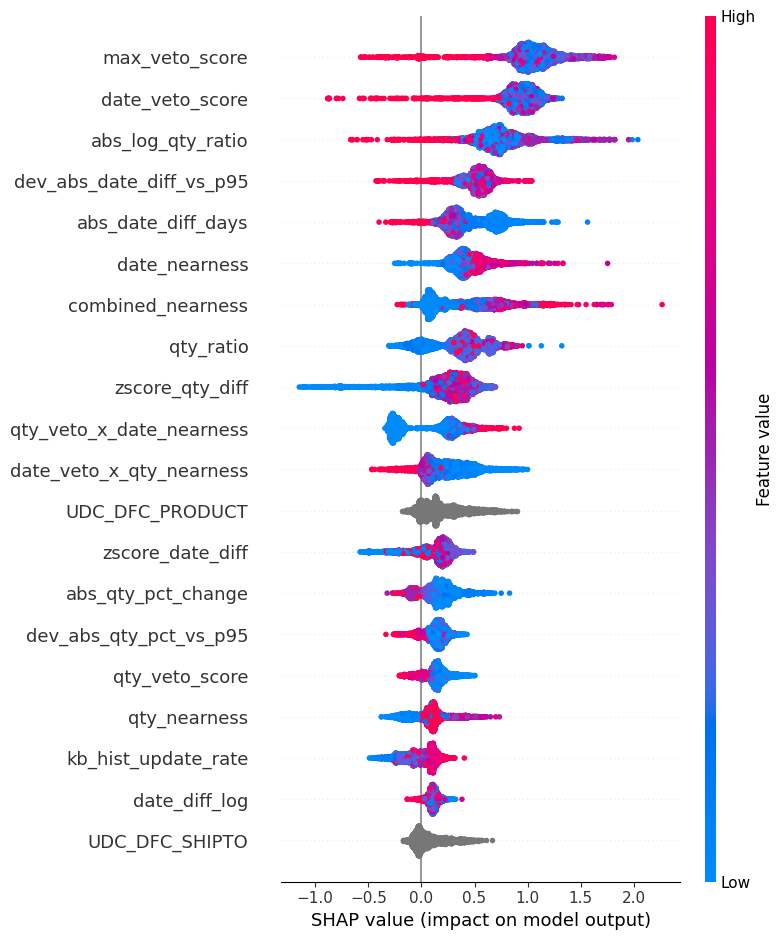

In [83]:
import shap

explainer = shap.TreeExplainer(group_model)

shap_values_fp = explainer.shap_values(fp_df)

shap.summary_plot(shap_values_fp, fp_df)

------

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

def analyze_thresholds(y_true, y_probs, thresholds=[0.5, 0.65, 0.72, 0.77, 0.8, 0.85]):
    results = []
    for t in thresholds:
        preds = (y_probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        
        results.append({
            "Threshold": t,
            "Precision": round(precision_score(y_true, preds, zero_division=0), 4),
            "Recall": round(recall_score(y_true, preds, zero_division=0), 4),
            "F1": round(f1_score(y_true, preds, zero_division=0), 4),
            "TP": tp, "TN": tn, "FP": fp, "FN": fn
        })
        
    df_results = pd.DataFrame(results)
    print("--- Threshold & Error Breakdown ---")
    print(df_results.to_string(index=False))
    return df_results

# EXECUTE:
df_thresh = analyze_thresholds(y_test, y_pred_proba)

In [ ]:
def analyze_error_features(df_test, y_true, y_probs, threshold=0.77):
    preds = (y_probs >= threshold).astype(int)
    df = df_test.copy()
    df['target'] = y_true
    df['pred'] = preds
    
    # Define the 4 buckets
    fp_mask = (df['pred'] == 1) & (df['target'] == 0)
    tn_mask = (df['pred'] == 0) & (df['target'] == 0)
    fn_mask = (df['pred'] == 0) & (df['target'] == 1)
    tp_mask = (df['pred'] == 1) & (df['target'] == 1)
    
    # Top features from your CatBoost importance
    features = [
        'max_veto_score', 'combined_nearness', 'abs_log_qty_ratio', 
        'zscore_qty_diff', 'abs_qty_pct_change', 'abs_date_diff_days'
    ]
    
    print(f"--- Feature Distributions at Threshold {threshold} ---")
    print(f"FP Count: {fp_mask.sum()} | TN Count: {tn_mask.sum()}")
    print(f"FN Count: {fn_mask.sum()} | TP Count: {tp_mask.sum()}\n")
    
    for feat in features:
        if feat not in df.columns: continue
        
        print(f"Feature: {feat}")
        print(f"  False Positives -> Median: {df.loc[fp_mask, feat].median():.4f} | 90th Pct: {df.loc[fp_mask, feat].quantile(0.9):.4f}")
        print(f"  True Negatives  -> Median: {df.loc[tn_mask, feat].median():.4f} | 90th Pct: {df.loc[tn_mask, feat].quantile(0.9):.4f}")
        print(f"  False Negatives -> Median: {df.loc[fn_mask, feat].median():.4f} | 90th Pct: {df.loc[fn_mask, feat].quantile(0.9):.4f}")
        print(f"  True Positives  -> Median: {df.loc[tp_mask, feat].median():.4f} | 90th Pct: {df.loc[tp_mask, feat].quantile(0.9):.4f}")
        print("-" * 40)

# EXECUTE:
analyze_error_features(df_test_final, y_test, y_pred_proba, threshold=0.77)

In [ ]:
def check_custom_slices(df_test, y_true, y_probs, threshold=0.77):
    preds = (y_probs >= threshold).astype(int)
    df = df_test.copy()
    
    # Define custom business slices
    slices = {
        "Date Match (<=1) & Extreme Qty (>2.0)": (df['abs_date_diff_days'] <= 1) & (df['abs_qty_pct_change'] > 2.0),
        "High Veto Score (>10)": (df['max_veto_score'] > 10),
        "Exact Date Match (0 days)": (df['abs_date_diff_days'] == 0),
        "High Combined Nearness (> median)": (df['combined_nearness'] > df['combined_nearness'].median())
    }
    
    results = []
    for slice_name, mask in slices.items():
        if mask.sum() == 0: continue
            
        y_slice_true = y_true[mask.values] if hasattr(mask, 'values') else y_true[mask]
        y_slice_pred = preds[mask.values] if hasattr(mask, 'values') else preds[mask]
        
        support = len(y_slice_true)
        positives = y_slice_true.sum()
        
        results.append({
            "Slice": slice_name,
            "Total N": support,
            "Actual Positives": positives,
            "Precision": round(precision_score(y_slice_true, y_slice_pred, zero_division=0), 4),
            "Recall": round(recall_score(y_slice_true, y_slice_pred, zero_division=0), 4),
            "F1": round(f1_score(y_slice_true, y_slice_pred, zero_division=0), 4)
        })
        
    df_slices = pd.DataFrame(results)
    print(f"--- Slice Performance at Threshold {threshold} ---")
    print(df_slices.to_string(index=False))

# EXECUTE:
check_custom_slices(df_test_final, y_test, y_pred_proba, threshold=0.77)

In [ ]:
def check_class_balance(y_train, y_test):
    train_pos = sum(y_train)
    train_total = len(y_train)
    test_pos = sum(y_test)
    test_total = len(y_test)
    
    print("--- Class Balance ---")
    print(f"Train: {train_pos}/{train_total} positives ({train_pos/train_total:.2%}) -> Ratio ~ 1:{int((train_total-train_pos)/train_pos)}")
    print(f"Test:  {test_pos}/{test_total} positives ({test_pos/test_total:.2%}) -> Ratio ~ 1:{int((test_total-test_pos)/test_pos)}")

# EXECUTE:
check_class_balance(y_train, y_test) # Make sure y_train is available in memory

In [ ]:
def check_calibration(y_true, y_probs, bins=10):
    df = pd.DataFrame({'true': y_true, 'prob': y_probs})
    # Create bins for probabilities
    df['prob_bin'] = pd.cut(df['prob'], bins=np.linspace(0, 1, bins+1))
    
    calib_df = df.groupby('prob_bin').agg(
        Count=('true', 'count'),
        Actual_Positive_Rate=('true', 'mean'),
        Mean_Predicted_Prob=('prob', 'mean')
    ).reset_index()
    
    # Filter out empty bins
    calib_df = calib_df[calib_df['Count'] > 0].copy()
    
    print("--- Calibration (Binned Probabilities) ---")
    print(calib_df.to_string(index=False))

# EXECUTE:
check_calibration(y_test, y_pred_proba)

In [ ]:
# print("\n--- All Groups in Knowledge Base ---")
# for idx, row in df_kb[JOIN_KEYS].drop_duplicates().iterrows():
#     print(f"Group {idx+1}: {row.to_dict()}")

In [ ]:
def get_kb_row_for_group(buyer_duns: str, seller_duns: str, product: str, shipto: str) -> pd.Series:
    """Extracts the knowledge base row for a group, with human-readable values.
    Log-space KB stats are back-converted to original scale for inspection."""
    group_data = {
        'UDC_BUYERDUNS': buyer_duns,
        'UDC_SELLERDUNS': seller_duns,
        'UDC_DFC_PRODUCT': product,
        'UDC_DFC_SHIPTO': shipto
    }

    kb_row = df_kb.loc[
        (df_kb['UDC_BUYERDUNS'] == group_data['UDC_BUYERDUNS']) &
        (df_kb['UDC_SELLERDUNS'] == group_data['UDC_SELLERDUNS']) &
        (df_kb['UDC_DFC_PRODUCT'] == group_data['UDC_DFC_PRODUCT']) &
        (df_kb['UDC_DFC_SHIPTO'] == group_data['UDC_DFC_SHIPTO'])
    ]

    if kb_row.empty:
        print(f"No knowledge base entry found for group: {group_data}")
        return pd.Series(dtype='object')

    row = kb_row.iloc[0].copy()

    def inv_signed_log(v):
        return np.sign(v) * np.expm1(np.abs(v))

    row['date_diff_mean (days)'] = inv_signed_log(row['kb_date_diff_log_mean'])
    row['date_diff_std (days)'] = np.expm1(row['kb_date_diff_log_std'])
    row['abs_date_diff_mean (days)'] = np.expm1(row['kb_abs_date_diff_log_mean'])
    row['abs_date_diff_p95 (days)'] = np.expm1(row['kb_abs_date_diff_log_p95'])
    row['qty_diff_mean (units)'] = inv_signed_log(row['kb_qty_diff_log_mean'])
    row['qty_diff_std (units)'] = np.expm1(row['kb_qty_diff_log_std'])
    row['abs_qty_pct_mean'] = row['kb_abs_qty_pct_mean']
    row['abs_qty_pct_p95'] = row['kb_abs_qty_pct_p95']
    row['abs_qty_pct_p99'] = row['kb_abs_qty_pct_p99']
    row['abs_date_diff_days_p95'] = row['kb_abs_date_diff_days_p95']
    row['abs_date_diff_days_p99'] = row['kb_abs_date_diff_days_p99']
    row['qty_veto_T'] = row['kb_qty_veto_T']
    row['date_veto_T'] = row['kb_date_veto_T']

    if 'kb_frac_postpone' in row.index:
        row['frac_postpone'] = row['kb_frac_postpone']
    if 'kb_frac_qty_increase' in row.index:
        row['frac_qty_increase'] = row['kb_frac_qty_increase']

    return row

In [ ]:
def get_prediction_score_for_pair(
    buyer_duns: str,
    seller_duns: str,
    product: str,
    shipto: str,
    forecast_date: str,
    forecast_qty: float,
    existing_date: str,
    existing_qty: float,
    snapshot_import_date: str
) -> float:
    """Returns the prediction score for a single pair."""
    # 1. Create a single-row DataFrame for the pair
    single_pair_df = pd.DataFrame([{
        'UDC_BUYERDUNS': buyer_duns,
        'UDC_SELLERDUNS': seller_duns,
        'UDC_DFC_PRODUCT': product,
        'UDC_DFC_SHIPTO': shipto,
        'forecast_date': pd.to_datetime(forecast_date),
        'forecast_qty': forecast_qty,
        'existing_date': pd.to_datetime(existing_date),
        'existing_qty': existing_qty,
        'SNAPSHOT_DFC_DOCID_IMPORT_DATE': pd.to_datetime(snapshot_import_date)
    }])

    # 2. Engineer pair features
    single_pair_df_fe = engineer_pair_features(single_pair_df)

    # 3. Merge with knowledge base
    single_pair_df_merged = merge_knowledge_base(single_pair_df_fe, df_kb, JOIN_KEYS)

    # 4. Add proximity features (must match training pipeline)
    if ENABLE_PROXIMITY_FEATURES:
        single_pair_df_merged = add_proximity_features(single_pair_df_merged, verbose=False)

    single_pair_df_merged = single_pair_df_merged.fillna(0)

    cols_to_drop_for_pred = [col for col in COLS_TO_DROP if col != TARGET]

    X_single_pair = single_pair_df_merged.drop(columns=cols_to_drop_for_pred, errors='ignore')

    # Ensure categorical features are string type for CatBoost
    for col in CAT_FEATURES:
        if col in X_single_pair.columns:
            X_single_pair[col] = X_single_pair[col].fillna('UNKNOWN').astype(str)

    # 5. Predict probability using the trained model
    prediction_pool = Pool(data=X_single_pair, cat_features=CAT_FEATURES)
    prediction_proba = model.predict_proba(prediction_pool)[:, 1]

    return prediction_proba[0]

In [ ]:
# 'UDC_BUYERDUNS': '001316827', 'UDC_SELLERDUNS': '001307032', 'UDC_DFC_PRODUCT': '000000000098894422', 'UDC_DFC_SHIPTO': '1702'}
# {'UDC_BUYERDUNS': '312819113', 'UDC_SELLERDUNS': '316097161', 'UDC_DFC_PRODUCT': 'SI600', 'UDC_DFC_SHIPTO': '201'}
# {'UDC_BUYERDUNS': '000X0FYCSA614', 'UDC_SELLERDUNS': '480000926', 'UDC_DFC_PRODUCT': '10000848', 'UDC_DFC_SHIPTO': '6140'}
kb_result_1 = get_kb_row_for_group('001316827', '001307032', '000000000098894422', '1702')
kb_result = get_kb_row_for_group('000X0FYCSA614', '480000926', '10000848', '6140')
print(kb_result_1.to_string())
print(kb_result.to_string())

In [ ]:
# {'UDC_BUYERDUNS': '000X0FYCSA614', 'UDC_SELLERDUNS': '480000926', 'UDC_DFC_PRODUCT': '10000848', 'UDC_DFC_SHIPTO': '6140'}

score_1 = get_prediction_score_for_pair('001316827', '001307032', '000000000098894422', '1702',
                                      '2026-03-01', 0, '2026-03-01', 60000, '2026-01-10')
score = get_prediction_score_for_pair('000X0FYCSA614', '480000926', '10000848', '6140',
                                      '2026-03-01', 0, '2026-03-01', 60000, '2026-01-10')
print(f"Prediction score_1 for sample pair: {score_1:.4f}")
print(f"Prediction score for sample pair: {score:.4f}")

In [ ]:
# 1316827	1307032	97169315	1702
# run_diagnostic_tests('001316827', '202108015', '000000000095628426', '4786')
# Call the method for the specified group
specific_group = {
    'UDC_BUYERDUNS': '001316827',
    'UDC_SELLERDUNS': '001307032',
    'UDC_DFC_PRODUCT': '000000000097169315',
    'UDC_DFC_SHIPTO': '1702'
}

print(f"\n--- Plotting for Group: {specific_group} ---")
plot_group_differences(
    df_input=df, # Using the 'df' DataFrame that contains raw and previous data
    buyer_duns=specific_group['UDC_BUYERDUNS'],
    seller_duns=specific_group['UDC_SELLERDUNS'],
    product=specific_group['UDC_DFC_PRODUCT'],
    shipto=specific_group['UDC_DFC_SHIPTO']
)

In [ ]:
from datetime import timedelta

def run_diagnostic_tests_with_threshold(
    buyer_duns: str,
    seller_duns: str,
    product: str,
    shipto: str,
    base_qty: float = None,
    base_date: str = '2026-03-15',
    snapshot_date: str = '2026-01-10',
    threshold: float = 0.72,
):
    """
    Run a comprehensive diagnostic test suite for any group.

    Systematically varies qty change and date change using the group's own
    KB statistics as reference points. Prints results with KB context,
    expected-result rationale, and full X_single_pair features for each test case.
    """
    kb_row = df_kb.loc[
        (df_kb['UDC_BUYERDUNS'] == buyer_duns) &
        (df_kb['UDC_SELLERDUNS'] == seller_duns) &
        (df_kb['UDC_DFC_PRODUCT'] == product) &
        (df_kb['UDC_DFC_SHIPTO'] == shipto)
    ]
    if kb_row.empty:
        print(f"ERROR: No KB entry for group ({buyer_duns}, {seller_duns}, {product}, {shipto})")
        return

    kb = kb_row.iloc[0]

    if base_qty is None:
        g = df[(df['UDC_BUYERDUNS'] == buyer_duns) & (df['UDC_SELLERDUNS'] == seller_duns) &
               (df['UDC_DFC_PRODUCT'] == product) & (df['UDC_DFC_SHIPTO'] == shipto)]
        base_qty = g['UDC_QTY'].median() if len(g) > 0 else 1000.0

    qty_pct_mean = kb['kb_abs_qty_pct_mean']
    qty_pct_p95 = kb['kb_abs_qty_pct_p95']
    qty_pct_p99 = kb['kb_abs_qty_pct_p99']
    qty_veto_T = kb['kb_qty_veto_T']
    frac_qty_inc = kb.get('kb_frac_qty_increase', 0.5)

    date_p95 = kb['kb_abs_date_diff_days_p95']
    date_p99 = kb['kb_abs_date_diff_days_p99']
    date_veto_T = kb['kb_date_veto_T']
    frac_postpone = kb.get('kb_frac_postpone', 0.5)

    qty_dir_label = "decrease" if frac_qty_inc < 0.5 else "increase"
    qty_dir_sign = -1 if frac_qty_inc < 0.5 else 1
    date_dir_label = "pull forward" if frac_postpone < 0.5 else "postpone"
    date_dir_sign = -1 if frac_postpone < 0.5 else 1

    header = (
        f"\n{'='*115}\n"
        f"  DIAGNOSTIC TESTS — Group: ({buyer_duns}, {seller_duns}, {product}, {shipto})\n"
        f"{'='*115}\n"
        f"  Base qty: {base_qty:,.0f} | Base date: {base_date} | Threshold: {threshold}\n"
        f"  KB qty:  mean_pct={qty_pct_mean:.2%} | p95={qty_pct_p95:.2%} | p99={qty_pct_p99:.2%}"
        f" | veto_T={qty_veto_T:.2f} | frac_increase={frac_qty_inc:.1%}"
        f" (dominant direction: {qty_dir_label})\n"
        f"  KB date: p95={date_p95:.0f}d | p99={date_p99:.0f}d | veto_T={date_veto_T:.0f}d"
        f" | frac_postpone={frac_postpone:.1%}"
        f" (dominant direction: {date_dir_label})\n"
        f"{'='*115}"
    )
    print(header)

    # Recreate pipeline locally to grab X_single_pair for diagnostics printing
    def _score_and_features(forecast_qty, existing_qty, forecast_dt, existing_dt):
        single_pair_df = pd.DataFrame([{
            'UDC_BUYERDUNS': buyer_duns,
            'UDC_SELLERDUNS': seller_duns,
            'UDC_DFC_PRODUCT': product,
            'UDC_DFC_SHIPTO': shipto,
            'forecast_date': pd.to_datetime(forecast_dt),
            'forecast_qty': forecast_qty,
            'existing_date': pd.to_datetime(existing_dt),
            'existing_qty': existing_qty,
            'SNAPSHOT_DFC_DOCID_IMPORT_DATE': pd.to_datetime(snapshot_date)
        }])

        single_pair_df_fe = engineer_pair_features(single_pair_df)
        single_pair_df_merged = merge_knowledge_base(single_pair_df_fe, df_kb, JOIN_KEYS)
        
        if ENABLE_PROXIMITY_FEATURES:
            single_pair_df_merged = add_proximity_features(single_pair_df_merged, verbose=False)

        single_pair_df_merged = single_pair_df_merged.fillna(0)
        cols_to_drop_for_pred = [col for col in COLS_TO_DROP if col != TARGET]
        X_sp = single_pair_df_merged.drop(columns=cols_to_drop_for_pred, errors='ignore')

        for col in CAT_FEATURES:
            if col in X_sp.columns:
                X_sp[col] = X_sp[col].fillna('UNKNOWN').astype(str)

        prediction_pool = Pool(data=X_sp, cat_features=CAT_FEATURES)
        prediction_proba = model.predict_proba(prediction_pool)[:, 1]

        return prediction_proba[0], X_sp

    def _print_row(test_id, description, score, pred, kb_ref, rationale, fq, eq, fd, ed, X_df):
        print(f"  {test_id:5s} | Score: {score:.4f} (Pred: {pred}) | {description}")
        print(f"        | F_Qty: {fq:<10,.2f} | E_Qty: {eq:<10,.2f} | F_Date: {fd} | E_Date: {ed}")
        print(f"        | kb_ref: {kb_ref}")
        print(f"        | reason: {rationale}")
        print(f"        | --- X_single_pair features ---")
        for col, val in X_df.iloc[0].items():
            print(f"        | {col}: {val}")
        print("\n")

    results = []

    def _run(test_id, desc, fq, eq, dd, kb_ref, rationale):
        existing_dt = pd.to_datetime(base_date)
        forecast_dt = existing_dt + timedelta(days=int(dd))
        
        s, X_sp = _score_and_features(fq, eq, forecast_dt, existing_dt)
        pred = 1 if s >= threshold else 0 
        
        fd_str = forecast_dt.strftime('%Y-%m-%d')
        ed_str = existing_dt.strftime('%Y-%m-%d')
        
        _print_row(test_id, desc, s, pred, kb_ref, rationale, fq, eq, fd_str, ed_str, X_sp)
        results.append({'id': test_id, 'desc': desc, 'score': s, 'pred': pred})

    # --- SECTION A: Qty Sweep (date_diff = 0) ---
    print(f"  --- A. QTY SWEEP (date_diff = 0 days, perfect date match) ---\n")

    tiny_typical_qty = base_qty * (1 + qty_dir_sign * 0.01)
    _run("A0", f"BASELINE: qty 1% {qty_dir_label} + date 1d (ideal pair)",
         tiny_typical_qty, base_qty, date_dir_sign * 1,
         f"tiny typical change on both dimensions",
         "Best realistic pair: small change in dominant direction on both dimensions.")

    tiny_dec_qty = base_qty * (1 + qty_dir_sign * 0.01)
    frac_dominant = (1 - frac_qty_inc) if qty_dir_sign < 0 else frac_qty_inc
    _run("A2", f"qty 1% {qty_dir_label} (dominant direction)",
         tiny_dec_qty, base_qty, 0,
         f"1% vs mean={qty_pct_mean:.2%}, frac_{qty_dir_label}={frac_dominant:.1%}",
         f"Tiny change in the group's dominant direction; should be nearly as high as A0")

    opp_dir_sign = -qty_dir_sign
    tiny_inc_qty = base_qty * (1 + opp_dir_sign * 0.01)
    opp_label = "increase" if qty_dir_sign < 0 else "decrease"
    frac_non_dominant = frac_qty_inc if qty_dir_sign < 0 else (1 - frac_qty_inc)
    _run("A3", f"qty 1% {opp_label} (non-dominant direction)",
         tiny_inc_qty, base_qty, 0,
         f"1% vs mean={qty_pct_mean:.2%}, frac_{opp_label}={frac_non_dominant:.1%}",
         f"Tiny change against the group's dominant direction; should be close to A2")

    small_qty = base_qty * (1 + qty_dir_sign * 0.10)
    _run("A4", f"qty 10% {qty_dir_label}",
         small_qty, base_qty, 0,
         f"10% vs mean={qty_pct_mean:.2%}, p95={qty_pct_p95:.2%}",
         f"Small change in dominant direction; within mean for most groups")

    mod_qty_dom = base_qty * (1 + qty_dir_sign * 0.50)
    _run("A5", f"qty 50% {qty_dir_label}",
         mod_qty_dom, base_qty, 0,
         f"50% vs mean={qty_pct_mean:.2%}, p95={qty_pct_p95:.2%}",
         f"Moderate change; near or beyond p95 for tight groups, within range for wide groups")

    mod_qty_opp = base_qty * (1 + opp_dir_sign * 0.50)
    _run("A6", f"qty 50% {opp_label} (non-dominant)",
         mod_qty_opp, base_qty, 0,
         f"50% wrong direction vs frac_{opp_label}={frac_non_dominant:.1%}",
         f"Moderate change against dominant direction; penalized more for directionally-biased groups")

    p95_qty = base_qty * (1 + qty_dir_sign * qty_pct_p95)
    _run("A7", f"qty at p95 ({qty_pct_p95:.0%} {qty_dir_label})",
         p95_qty, base_qty, 0,
         f"exactly at p95={qty_pct_p95:.2%}",
         f"Boundary of historically normal changes; score should drop accordingly")

    p99_qty = base_qty * (1 + qty_dir_sign * qty_pct_p99)
    _run("A8", f"qty at p99 ({qty_pct_p99:.0%} {qty_dir_label})",
         p99_qty, base_qty, 0,
         f"exactly at p99={qty_pct_p99:.2%}, approaching veto_T={qty_veto_T:.2f}",
         f"Rare territory; only 1% of historical updates this large")

    extreme_pct = 5 * qty_pct_p95
    extreme_qty = max(base_qty * (1 + qty_dir_sign * extreme_pct), 0)
    _run("A9", f"qty 5x p95 ({extreme_pct:.0%} {qty_dir_label})",
         extreme_qty, base_qty, 0,
         f"5*p95={extreme_pct:.2%} vs veto_T={qty_veto_T:.2f}",
         f"Far beyond historical range; veto features should heavily penalize")

    # --- SECTION B: Date Sweep (qty_diff = 0) ---
    print(f"  --- B. DATE SWEEP (qty = 0% change, perfect qty match) ---\n")

    _run("B2", f"date 1 day ({date_dir_label}, dominant)",
         base_qty, base_qty, date_dir_sign * 1,
         f"1d vs p95={date_p95:.0f}d, frac_postpone={frac_postpone:.1%}",
         f"Tiny date shift in dominant direction; should score high")

    _run("B3", f"date 1 day ({'postpone' if date_dir_sign < 0 else 'pull forward'}, non-dominant)",
         base_qty, base_qty, -date_dir_sign * 1,
         f"1d opposite direction vs frac_postpone={frac_postpone:.1%}",
         f"Tiny date shift against dominant direction; should be close to B2 (only 1 day)")

    _run("B4", f"date 3 days ({date_dir_label})",
         base_qty, base_qty, date_dir_sign * 3,
         f"3d vs p95={date_p95:.0f}d",
         f"Small date shift; within normal range for most groups")

    _run("B5", f"date at p95 ({date_p95:.0f} days)",
         base_qty, base_qty, date_dir_sign * int(date_p95),
         f"exactly at p95={date_p95:.0f}d",
         f"Boundary of normal date changes; score should drop noticeably")

    _run("B6", f"date at p99 ({date_p99:.0f} days)",
         base_qty, base_qty, date_dir_sign * int(date_p99),
         f"exactly at p99={date_p99:.0f}d, veto_T={date_veto_T:.0f}d",
         f"Rare date territory; only 1% of historical updates shift this much")

    _run("B7", f"date at veto_T ({date_veto_T:.0f} days)",
         base_qty, base_qty, date_dir_sign * int(date_veto_T),
         f"at veto_T={date_veto_T:.0f}d — date_veto_score=1.0",
         f"Date veto threshold; score should be low despite perfect qty match")

    _run("B8", f"date 3x veto_T ({3*date_veto_T:.0f} days)",
         base_qty, base_qty, date_dir_sign * int(3 * date_veto_T),
         f"3*veto_T={3*date_veto_T:.0f}d — date_veto_score clipped at 10",
         f"Extreme date deviation; should be near zero")

    # --- SECTION C: Combined Scenarios ---
    print(f"  --- C. COMBINED SCENARIOS (qty + date varied together) ---\n")

    small_qty_c1 = base_qty * (1 + qty_dir_sign * 0.01)
    _run("C1", f"qty 1% {qty_dir_label} + date 1d (ideal realistic pair)",
         small_qty_c1, base_qty, date_dir_sign * 1,
         f"tiny typical change on both — same as A0 baseline",
         f"Best realistic combined pair; should be highest score in C section")

    small_qty_c = base_qty * (1 + qty_dir_sign * 0.05)
    _run("C2", f"qty 5% {qty_dir_label} + date 2d",
         small_qty_c, base_qty, date_dir_sign * 2,
         f"5% vs mean={qty_pct_mean:.2%} + 2d vs p95={date_p95:.0f}d",
         f"Small realistic update on both dimensions; should be solidly positive")

    small_qty_c2 = base_qty * (1 + qty_dir_sign * 0.10)
    _run("C3", f"qty 10% {qty_dir_label} + date at p95 ({date_p95:.0f}d)",
         small_qty_c2, base_qty, date_dir_sign * int(date_p95),
         f"10% vs p95={qty_pct_p95:.2%} + date at p95={date_p95:.0f}d",
         f"One dimension at boundary, other small; score should drop")

    p95_qty_c = base_qty * (1 + qty_dir_sign * qty_pct_p95)
    _run("C4", f"qty at p95 ({qty_pct_p95:.0%}) + date 0d",
         p95_qty_c, base_qty, 0,
         f"qty at p95={qty_pct_p95:.2%} + perfect date",
         f"Date is perfect but qty at boundary; tests whether date match rescues extreme qty")

    _run("C5", f"qty 0% + date at veto_T ({date_veto_T:.0f}d)",
         base_qty, base_qty, date_dir_sign * int(date_veto_T),
         f"perfect qty + date at veto_T={date_veto_T:.0f}d",
         f"Qty is perfect but date at veto; tests whether qty match rescues extreme date")

    p95_qty_c2 = base_qty * (1 + qty_dir_sign * qty_pct_p95)
    _run("C6", f"qty at p95 + date at p95",
         p95_qty_c2, base_qty, date_dir_sign * int(date_p95),
         f"qty at p95={qty_pct_p95:.2%} + date at p95={date_p95:.0f}d",
         f"Both dimensions at boundary simultaneously; should be low")

    # --- Summary ---
    # print(f"  --- SUMMARY ---\n")
    
    # mono_violations = []
    # for i in range(len(results) - 1):
    #     a, b = results[i], results[i + 1]
    #     if a['id'][0] == b['id'][0] and a['id'][0] in ('A', 'B'):
    #         if b['score'] > a['score'] + 0.05:
    #             mono_violations.append(f"    {a['id']} ({a['score']:.4f}) < {b['id']} ({b['score']:.4f})"
    #                                    f"  — {a['desc']} should score >= {b['desc']}")
    # if mono_violations:
    #     print(f"  Monotonicity violations (within A/B sweeps, tolerance=0.05):")
    #     for v in mono_violations:
    #         print(v)
    # else:
    #     print(f"  Monotonicity: No violations detected within A/B sweeps ✓")

    return results

In [ ]:
# run_diagnostic_tests('001316827', '001307032', '000000000098894422', '1702')
# 000X0FYCSA614_seller_480000926_product_10000848_shipto_6140
run_diagnostic_tests_with_threshold('000X0FYCSA614', '480000926', '10000848', '6140')
run_diagnostic_tests_with_threshold('001316827', '315000554', '000000000095565742', '4106')
# Plotting Group 43: {'UDC_BUYERDUNS': '001316827', 'UDC_SELLERDUNS': '202108015', 'UDC_DFC_PRODUCT': '000000000095628426', 'UDC_DFC_SHIPTO': '4786'}

In [ ]:
# def run_diagnostic_tests(
#     buyer_duns: str,
#     seller_duns: str,
#     product: str,
#     shipto: str,
#     base_qty: float = None,
#     base_date: str = '2026-03-15',
#     snapshot_date: str = '2026-01-10',
# ):
#     """
#     Run a comprehensive diagnostic test suite for any group.

#     Systematically varies qty change and date change using the group's own
#     KB statistics as reference points. Prints results with KB context and
#     expected-result rationale for each test case.

#     Parameters:
#       base_qty: representative qty for the group. If None, uses the median
#                 of UDC_QTY for the group from the raw data.
#       base_date: anchor date for the existing order side.
#       snapshot_date: snapshot import date for all test pairs.
#     """
#     kb_row = df_kb.loc[
#         (df_kb['UDC_BUYERDUNS'] == buyer_duns) &
#         (df_kb['UDC_SELLERDUNS'] == seller_duns) &
#         (df_kb['UDC_DFC_PRODUCT'] == product) &
#         (df_kb['UDC_DFC_SHIPTO'] == shipto)
#     ]
#     if kb_row.empty:
#         print(f"ERROR: No KB entry for group ({buyer_duns}, {seller_duns}, {product}, {shipto})")
#         return

#     kb = kb_row.iloc[0]

#     if base_qty is None:
#         g = df[(df['UDC_BUYERDUNS'] == buyer_duns) & (df['UDC_SELLERDUNS'] == seller_duns) &
#                (df['UDC_DFC_PRODUCT'] == product) & (df['UDC_DFC_SHIPTO'] == shipto)]
#         base_qty = g['UDC_QTY'].median() if len(g) > 0 else 1000.0

#     qty_pct_mean = kb['kb_abs_qty_pct_mean']
#     qty_pct_p95 = kb['kb_abs_qty_pct_p95']
#     qty_pct_p99 = kb['kb_abs_qty_pct_p99']
#     qty_veto_T = kb['kb_qty_veto_T']
#     frac_qty_inc = kb.get('kb_frac_qty_increase', 0.5)

#     date_p95 = kb['kb_abs_date_diff_days_p95']
#     date_p99 = kb['kb_abs_date_diff_days_p99']
#     date_veto_T = kb['kb_date_veto_T']
#     frac_postpone = kb.get('kb_frac_postpone', 0.5)

#     qty_dir_label = "decrease" if frac_qty_inc < 0.5 else "increase"
#     qty_dir_sign = -1 if frac_qty_inc < 0.5 else 1
#     date_dir_label = "pull forward" if frac_postpone < 0.5 else "postpone"
#     date_dir_sign = -1 if frac_postpone < 0.5 else 1

#     def _expected_range(qty_pct_change, date_diff_days, is_both_zero=False):
#         """Compute expected score range based on group's own KB stats.
#         Uses veto thresholds and percentiles to set realistic expectations."""
#         if is_both_zero:
#             return (0.0, 0.20)

#         qv = abs(qty_pct_change) / (qty_veto_T + 1e-6)
#         dv = abs(date_diff_days) / (date_veto_T + 1e-6)
#         worst_veto = max(qv, dv)

#         if worst_veto > 5:
#             return (0.0, 0.15)
#         elif worst_veto > 2:
#             return (0.0, 0.35)
#         elif worst_veto > 1:
#             hi = 0.60 - 0.10 * (worst_veto - 1)
#             return (0.02, max(hi, 0.35))
#         else:
#             qty_rel = abs(qty_pct_change) / (qty_pct_p95 + 1e-6)
#             date_rel = abs(date_diff_days) / (date_p95 + 1e-6)
#             worst_rel = max(qty_rel, date_rel)

#             if worst_rel > 2:
#                 return (0.15, 0.90)
#             elif worst_rel > 1:
#                 return (0.25, 0.98)
#             elif worst_rel > 0.5:
#                 return (0.40, 1.00)
#             else:
#                 return (0.60, 1.00)

#     header = (
#         f"\n{'='*100}\n"
#         f"  DIAGNOSTIC TESTS — Group: ({buyer_duns}, {seller_duns}, {product}, {shipto})\n"
#         f"{'='*100}\n"
#         f"  Base qty: {base_qty:,.0f} | Base date: {base_date}\n"
#         f"  KB qty:  mean_pct={qty_pct_mean:.2%} | p95={qty_pct_p95:.2%} | p99={qty_pct_p99:.2%}"
#         f" | veto_T={qty_veto_T:.2f} | frac_increase={frac_qty_inc:.1%}"
#         f" (dominant direction: {qty_dir_label})\n"
#         f"  KB date: p95={date_p95:.0f}d | p99={date_p99:.0f}d | veto_T={date_veto_T:.0f}d"
#         f" | frac_postpone={frac_postpone:.1%}"
#         f" (dominant direction: {date_dir_label})\n"
#         f"{'='*100}"
#     )
#     print(header)

#     def _score(forecast_qty, existing_qty, date_diff_days):
#         from datetime import timedelta
#         existing_dt = pd.to_datetime(base_date)
#         forecast_dt = existing_dt + timedelta(days=int(date_diff_days))
#         return get_prediction_score_for_pair(
#             buyer_duns, seller_duns, product, shipto,
#             forecast_dt.strftime('%Y-%m-%d'), forecast_qty,
#             existing_dt.strftime('%Y-%m-%d'), existing_qty,
#             snapshot_date
#         )

#     def _print_row(test_id, description, score, kb_ref, rationale, expected):
#         status = "✓" if expected[0] <= score <= expected[1] else "✗"
#         print(f"  {test_id:5s} | {score:.4f} | expected [{expected[0]:.2f}-{expected[1]:.2f}] {status}"
#               f" | {description}")
#         print(f"        |        | kb_ref: {kb_ref}")
#         print(f"        |        | reason: {rationale}")
#         print(f"        |")

#     results = []

#     def _run(test_id, desc, fq, eq, dd, kb_ref, rationale, expected):
#         s = _score(fq, eq, dd)
#         _print_row(test_id, desc, s, kb_ref, rationale, expected)
#         results.append({'id': test_id, 'desc': desc, 'score': s,
#                         'exp_lo': expected[0], 'exp_hi': expected[1]})

#     # --- SECTION A: Qty Sweep (date_diff = 0) ---
#     print(f"\n  --- A. QTY SWEEP (date_diff = 0 days, perfect date match) ---\n")

#     tiny_typical_qty = base_qty * (1 + qty_dir_sign * 0.01)
#     _run("A0", f"BASELINE: qty 1% {qty_dir_label} + date 1d (ideal pair)",
#          tiny_typical_qty, base_qty, date_dir_sign * 1,
#          f"tiny typical change on both dimensions",
#          "Best realistic pair: small change in dominant direction on both dimensions. "
#          "Training positives always have at least one non-zero dimension, so this is the true ideal.",
#          (0.75, 1.0))

#     _run("A1", "qty 0% + date 0d (both zero — NOT an update)",
#          base_qty, base_qty, 0,
#          f"is_update=1 requires date OR qty to differ — both-zero never appears as a positive pair",
#          "Both dimensions exactly zero means 'nothing changed' which is NOT an update. "
#          "Expected LOW because no positive training pair has both zero.",
#          _expected_range(0, 0, is_both_zero=True))

#     tiny_dec_qty = base_qty * (1 + qty_dir_sign * 0.01)
#     frac_dominant = (1 - frac_qty_inc) if qty_dir_sign < 0 else frac_qty_inc
#     _run("A2", f"qty 1% {qty_dir_label} (dominant direction)",
#          tiny_dec_qty, base_qty, 0,
#          f"1% vs mean={qty_pct_mean:.2%}, frac_{qty_dir_label}={frac_dominant:.1%}",
#          f"Tiny change in the group's dominant direction; should be nearly as high as A0",
#          _expected_range(0.01, 0))

#     opp_dir_sign = -qty_dir_sign
#     tiny_inc_qty = base_qty * (1 + opp_dir_sign * 0.01)
#     opp_label = "increase" if qty_dir_sign < 0 else "decrease"
#     frac_non_dominant = frac_qty_inc if qty_dir_sign < 0 else (1 - frac_qty_inc)
#     _run("A3", f"qty 1% {opp_label} (non-dominant direction)",
#          tiny_inc_qty, base_qty, 0,
#          f"1% vs mean={qty_pct_mean:.2%}, frac_{opp_label}={frac_non_dominant:.1%}",
#          f"Tiny change against the group's dominant direction; should be close to A2 (magnitude is tiny)",
#          _expected_range(0.01, 0))

#     small_qty = base_qty * (1 + qty_dir_sign * 0.10)
#     _run("A4", f"qty 10% {qty_dir_label}",
#          small_qty, base_qty, 0,
#          f"10% vs mean={qty_pct_mean:.2%}, p95={qty_pct_p95:.2%}",
#          f"Small change in dominant direction; within mean for most groups",
#          _expected_range(0.10, 0))

#     mod_qty_dom = base_qty * (1 + qty_dir_sign * 0.50)
#     _run("A5", f"qty 50% {qty_dir_label}",
#          mod_qty_dom, base_qty, 0,
#          f"50% vs mean={qty_pct_mean:.2%}, p95={qty_pct_p95:.2%}",
#          f"Moderate change; near or beyond p95 for tight groups, within range for wide groups",
#          _expected_range(0.50, 0))

#     mod_qty_opp = base_qty * (1 + opp_dir_sign * 0.50)
#     _run("A6", f"qty 50% {opp_label} (non-dominant)",
#          mod_qty_opp, base_qty, 0,
#          f"50% wrong direction vs frac_{opp_label}={frac_non_dominant:.1%}",
#          f"Moderate change against dominant direction; penalized more for directionally-biased groups",
#          _expected_range(0.50, 0))

#     p95_qty = base_qty * (1 + qty_dir_sign * qty_pct_p95)
#     _run("A7", f"qty at p95 ({qty_pct_p95:.0%} {qty_dir_label})",
#          p95_qty, base_qty, 0,
#          f"exactly at p95={qty_pct_p95:.2%}",
#          f"Boundary of historically normal changes; score should be moderate-to-low",
#          _expected_range(qty_pct_p95, 0))

#     p99_qty = base_qty * (1 + qty_dir_sign * qty_pct_p99)
#     _run("A8", f"qty at p99 ({qty_pct_p99:.0%} {qty_dir_label})",
#          p99_qty, base_qty, 0,
#          f"exactly at p99={qty_pct_p99:.2%}, approaching veto_T={qty_veto_T:.2f}",
#          f"Rare territory; only 1% of historical updates this large",
#          _expected_range(qty_pct_p99, 0))

#     extreme_pct = 5 * qty_pct_p95
#     extreme_qty = max(base_qty * (1 + qty_dir_sign * extreme_pct), 0)
#     _run("A9", f"qty 5x p95 ({extreme_pct:.0%} {qty_dir_label})",
#          extreme_qty, base_qty, 0,
#          f"5*p95={extreme_pct:.2%} vs veto_T={qty_veto_T:.2f}",
#          f"Far beyond historical range; veto features should heavily penalize",
#          _expected_range(extreme_pct, 0))

#     absurd_qty = base_qty * 900
#     _run("A10", "qty 89900% increase (absurd)",
#          absurd_qty, base_qty, 0,
#          f"89900% vs veto_T={qty_veto_T:.2f} — veto_score would be clipped at 10",
#          f"Physically impossible change; score should be near zero regardless of date match",
#          _expected_range(899.0, 0))

#     # --- SECTION B: Date Sweep (qty_diff = 0) ---
#     print(f"\n  --- B. DATE SWEEP (qty = 0% change, perfect qty match) ---\n")

#     _run("B1", "date 0d + qty 0% (both zero — NOT an update)",
#          base_qty, base_qty, 0,
#          f"same as A1 — both-zero is not an update",
#          f"Duplicates A1. Both dimensions zero means nothing changed — not a match.",
#          _expected_range(0, 0, is_both_zero=True))

#     _run("B2", f"date 1 day ({date_dir_label}, dominant)",
#          base_qty, base_qty, date_dir_sign * 1,
#          f"1d vs p95={date_p95:.0f}d, frac_postpone={frac_postpone:.1%}",
#          f"Tiny date shift in dominant direction; should score high",
#          _expected_range(0, 1))

#     _run("B3", f"date 1 day ({'postpone' if date_dir_sign < 0 else 'pull forward'}, non-dominant)",
#          base_qty, base_qty, -date_dir_sign * 1,
#          f"1d opposite direction vs frac_postpone={frac_postpone:.1%}",
#          f"Tiny date shift against dominant direction; should be close to B2 (only 1 day)",
#          _expected_range(0, 1))

#     _run("B4", f"date 3 days ({date_dir_label})",
#          base_qty, base_qty, date_dir_sign * 3,
#          f"3d vs p95={date_p95:.0f}d",
#          f"Small date shift; within normal range for most groups",
#          _expected_range(0, 3))

#     _run("B5", f"date at p95 ({date_p95:.0f} days)",
#          base_qty, base_qty, date_dir_sign * int(date_p95),
#          f"exactly at p95={date_p95:.0f}d",
#          f"Boundary of normal date changes; score should drop noticeably",
#          _expected_range(0, date_p95))

#     _run("B6", f"date at p99 ({date_p99:.0f} days)",
#          base_qty, base_qty, date_dir_sign * int(date_p99),
#          f"exactly at p99={date_p99:.0f}d, veto_T={date_veto_T:.0f}d",
#          f"Rare date territory; only 1% of historical updates shift this much",
#          _expected_range(0, date_p99))

#     _run("B7", f"date at veto_T ({date_veto_T:.0f} days)",
#          base_qty, base_qty, date_dir_sign * int(date_veto_T),
#          f"at veto_T={date_veto_T:.0f}d — date_veto_score=1.0",
#          f"Date veto threshold; score should be low despite perfect qty match",
#          _expected_range(0, date_veto_T))

#     _run("B8", f"date 3x veto_T ({3*date_veto_T:.0f} days)",
#          base_qty, base_qty, date_dir_sign * int(3 * date_veto_T),
#          f"3*veto_T={3*date_veto_T:.0f}d — date_veto_score clipped at 10",
#          f"Extreme date deviation; should be near zero",
#          _expected_range(0, 3 * date_veto_T))

#     # --- SECTION C: Combined Scenarios ---
#     print(f"\n  --- C. COMBINED SCENARIOS (qty + date varied together) ---\n")

#     small_qty_c1 = base_qty * (1 + qty_dir_sign * 0.01)
#     _run("C1", f"qty 1% {qty_dir_label} + date 1d (ideal realistic pair)",
#          small_qty_c1, base_qty, date_dir_sign * 1,
#          f"tiny typical change on both — same as A0 baseline",
#          f"Best realistic combined pair; should be the highest score in the C section",
#          (0.75, 1.0))

#     small_qty_c = base_qty * (1 + qty_dir_sign * 0.05)
#     _run("C2", f"qty 5% {qty_dir_label} + date 2d",
#          small_qty_c, base_qty, date_dir_sign * 2,
#          f"5% vs mean={qty_pct_mean:.2%} + 2d vs p95={date_p95:.0f}d",
#          f"Small realistic update on both dimensions; should be solidly positive",
#          _expected_range(0.05, 2))

#     small_qty_c2 = base_qty * (1 + qty_dir_sign * 0.10)
#     _run("C3", f"qty 10% {qty_dir_label} + date at p95 ({date_p95:.0f}d)",
#          small_qty_c2, base_qty, date_dir_sign * int(date_p95),
#          f"10% vs p95={qty_pct_p95:.2%} + date at p95={date_p95:.0f}d",
#          f"One dimension at boundary, other small; score should be moderate",
#          _expected_range(0.10, date_p95))

#     p95_qty_c = base_qty * (1 + qty_dir_sign * qty_pct_p95)
#     _run("C4", f"qty at p95 ({qty_pct_p95:.0%}) + date 0d",
#          p95_qty_c, base_qty, 0,
#          f"qty at p95={qty_pct_p95:.2%} + perfect date",
#          f"Date is perfect but qty at boundary; tests whether date match rescues extreme qty",
#          _expected_range(qty_pct_p95, 0))

#     _run("C5", f"qty 0% + date at veto_T ({date_veto_T:.0f}d)",
#          base_qty, base_qty, date_dir_sign * int(date_veto_T),
#          f"perfect qty + date at veto_T={date_veto_T:.0f}d",
#          f"Qty is perfect but date at veto; tests whether qty match rescues extreme date",
#          _expected_range(0, date_veto_T))

#     p95_qty_c2 = base_qty * (1 + qty_dir_sign * qty_pct_p95)
#     _run("C6", f"qty at p95 + date at p95",
#          p95_qty_c2, base_qty, date_dir_sign * int(date_p95),
#          f"qty at p95={qty_pct_p95:.2%} + date at p95={date_p95:.0f}d",
#          f"Both dimensions at boundary simultaneously; should be low",
#          _expected_range(qty_pct_p95, date_p95))

#     _run("C7", "qty 89900% + date 0d (veto stress test)",
#          base_qty * 900, base_qty, 0,
#          f"89900% vs veto_T={qty_veto_T:.2f} + perfect date",
#          f"Absurd qty with perfect date; tests if veto overrides the date signal",
#          _expected_range(899.0, 0))

#     # --- Summary ---
#     print(f"\n  --- SUMMARY ---\n")
#     n_pass = sum(1 for r in results if r['exp_lo'] <= r['score'] <= r['exp_hi'])
#     n_total = len(results)
#     print(f"  Passed: {n_pass}/{n_total}")
#     print()

#     mono_violations = []
#     for i in range(len(results) - 1):
#         a, b = results[i], results[i + 1]
#         if a['id'][0] == b['id'][0] and a['id'][0] in ('A', 'B'):
#             if b['score'] > a['score'] + 0.05:
#                 mono_violations.append(f"    {a['id']} ({a['score']:.4f}) < {b['id']} ({b['score']:.4f})"
#                                        f"  — {a['desc']} should score >= {b['desc']}")
#     if mono_violations:
#         print(f"  Monotonicity violations (within A/B sweeps, tolerance=0.05):")
#         for v in mono_violations:
#             print(v)
#     else:
#         print(f"  Monotonicity: No violations detected within A/B sweeps ✓")

#     return results

In [ ]:
# import joblib
# import json

# # 1. Download the trained model
# model_path = "D:\TenupProjects\elemica\code\supplier-portal-fc-smartmatch-app\model.pkl"
# joblib.dump(model, model_path)
# print(f"Model downloaded to {model_path}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
from typing import List

def download_group_distribution_plot(
    df_raw: pd.DataFrame,
    df_kb: pd.DataFrame,
    buyer_duns: str,
    seller_duns: str,
    product: str,
    shipto: str,
    save_path: str,
    join_keys: List[str] = None,
    df_pairs_merged: pd.DataFrame = None,
):
    """
    Build and save a multi-panel data distribution plot for one group.
    Panels: change in date, change in pct qty, change in qty, deviation vs p95, KB table.
    """
    if join_keys is None:
        join_keys = ['UDC_BUYERDUNS', 'UDC_SELLERDUNS', 'UDC_DFC_PRODUCT', 'UDC_DFC_SHIPTO']

    group_mask = (
        (df_raw['UDC_BUYERDUNS'] == buyer_duns) &
        (df_raw['UDC_SELLERDUNS'] == seller_duns) &
        (df_raw['UDC_DFC_PRODUCT'] == product) &
        (df_raw['UDC_DFC_SHIPTO'] == shipto)
    )
    updates = df_raw[group_mask & (df_raw['is_update'] == 1)].dropna(
        subset=['UDC_PREVIOUS_DELIVERY_DATE', 'UDC_PREVIOUS_QTY']
    ).copy()

    if updates.empty:
        print(f"No update data for group ({buyer_duns}, {seller_duns}, {product}, {shipto}); skipping plot.")
        return

    eps = 1e-6
    date_change_days = (updates['UDC_DELIVERY_DATE'] - updates['UDC_PREVIOUS_DELIVERY_DATE']).dt.days
    qty_change = updates['UDC_QTY'] - updates['UDC_PREVIOUS_QTY']
    abs_qty_pct = (updates['UDC_QTY'] - updates['UDC_PREVIOUS_QTY']).abs() / (updates['UDC_PREVIOUS_QTY'].abs() + eps)

    kb_row = df_kb.loc[
        (df_kb['UDC_BUYERDUNS'] == buyer_duns) &
        (df_kb['UDC_SELLERDUNS'] == seller_duns) &
        (df_kb['UDC_DFC_PRODUCT'] == product) &
        (df_kb['UDC_DFC_SHIPTO'] == shipto)
    ]
    if kb_row.empty:
        print(f"No KB row for group ({buyer_duns}, {seller_duns}, {product}, {shipto}); skipping plot.")
        return
    kb = kb_row.iloc[0]

    dev_date = dev_qty = None
    if df_pairs_merged is not None:
        g = df_pairs_merged[
            (df_pairs_merged['UDC_BUYERDUNS'] == buyer_duns) &
            (df_pairs_merged['UDC_SELLERDUNS'] == seller_duns) &
            (df_pairs_merged['UDC_DFC_PRODUCT'] == product) &
            (df_pairs_merged['UDC_DFC_SHIPTO'] == shipto) &
            (df_pairs_merged['label'] == 1)
        ]
        if not g.empty and 'dev_abs_date_diff_vs_p95' in g.columns:
            dev_date = g['dev_abs_date_diff_vs_p95'].dropna()
            dev_qty = g['dev_abs_qty_pct_vs_p95'].dropna()
            
    if dev_date is None or (isinstance(dev_date, pd.Series) and dev_date.empty):
        # Fallback to engineering features if merged df is not provided or empty
        pairs = pd.DataFrame({
            'UDC_BUYERDUNS': updates['UDC_BUYERDUNS'].values,
            'UDC_SELLERDUNS': updates['UDC_SELLERDUNS'].values,
            'UDC_DFC_PRODUCT': updates['UDC_DFC_PRODUCT'].values,
            'UDC_DFC_SHIPTO': updates['UDC_DFC_SHIPTO'].values,
            'forecast_date': updates['UDC_DELIVERY_DATE'].values,
            'forecast_qty': updates['UDC_QTY'].values,
            'existing_date': updates['UDC_PREVIOUS_DELIVERY_DATE'].values,
            'existing_qty': updates['UDC_PREVIOUS_QTY'].values,
            'SNAPSHOT_DFC_DOCID_IMPORT_DATE': updates['SNAPSHOT_DFC_DOCID_IMPORT_DATE'].values,
        })
        fe = engineer_pair_features(pairs)
        merged = merge_knowledge_base(fe, df_kb, join_keys)
        dev_date = merged['dev_abs_date_diff_vs_p95'].dropna()
        dev_qty = merged['dev_abs_qty_pct_vs_p95'].dropna()

    fig = plt.figure(figsize=(14, 12))
    gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.25)
    fig.suptitle(
        f"Group: BuyerDUN={buyer_duns}, SellerDUN={seller_duns}, Product={product}, ShipTo={shipto}",
        fontsize=11, y=1.02
    )

    # Panel 1: Change in date
    ax0 = fig.add_subplot(gs[0, 0])
    sns.histplot(date_change_days, bins=30, kde=True, ax=ax0)
    ax0.axvline(0, color='red', linestyle='--', alpha=0.8)
    ax0.set_title('Change in date (days)')
    ax0.set_xlabel('Date change (days)')

    # Panel 2: Change in pct qty (abs)
    ax1 = fig.add_subplot(gs[0, 1])
    sns.histplot(abs_qty_pct, bins=30, kde=True, ax=ax1)
    ax1.set_title('Change in pct qty (abs)')
    ax1.set_xlabel('|qty change| / |previous qty|')

    # Panel 3: Change in qty (Replaced Directional Pattern)
    ax2 = fig.add_subplot(gs[1, 0])
    sns.histplot(qty_change, bins=30, kde=True, ax=ax2, color='seagreen')
    ax2.axvline(0, color='red', linestyle='--', alpha=0.8)
    ax2.set_title('Change in qty')
    ax2.set_xlabel('Qty change (units)')

    # Panel 4: Deviation vs p95
    ax3 = fig.add_subplot(gs[1, 1])
    if dev_date is not None and len(dev_date) > 0 and dev_qty is not None and len(dev_qty) > 0:
        ax3.hist(dev_date, bins=min(25, max(len(dev_date)//5, 5)), alpha=0.6, label='Date vs p95', color='steelblue', density=True)
        ax3.hist(dev_qty, bins=min(25, max(len(dev_qty)//5, 5)), alpha=0.6, label='Qty vs p95', color='seagreen', density=True)
        ax3.axvline(1.0, color='red', linestyle='--', alpha=0.8)
        ax3.set_title('Deviation vs p95')
        ax3.set_xlabel('dev_abs_*_vs_p95')
        ax3.legend(fontsize=8)
    else:
        ax3.text(0.5, 0.5, 'No deviation data', ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title('Deviation vs p95')

    # Panel 5: KB table
    ax_tab = fig.add_subplot(gs[2, :])
    ax_tab.axis('off')
    kb_cols = [c for c in df_kb.columns if c.startswith('kb_') and c not in join_keys]
    cell_text = []
    for c in kb_cols:
        v = kb.get(c, np.nan)
        if isinstance(v, (int, float)) and np.isfinite(v):
            cell_text.append([c, str(round(v, 4))])
        else:
            cell_text.append([c, str(v)])
    
    if cell_text:
        tbl = ax_tab.table(
            cellText=cell_text,
            colLabels=['Metric', 'Value'],
            loc='center',
            cellLoc='left',
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(7)

    os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close('all')

In [ ]:
# import os
# import time
# import matplotlib.pyplot as plt
# from tqdm import tqdm

# # 1. Define the directory
# REPORT_PLOTS_DIR = r"D:\TenupProjects\elemica\report_plots_100"
# os.makedirs(REPORT_PLOTS_DIR, exist_ok=True)

# # 2. Define the sanitize function (Fixes your "not defined" error)
# def _sanitize(s):
#     """Replaces filesystem-illegal characters with underscores."""
#     return str(s).replace("\\", "_").replace("/", "_").replace(":", "_").replace("*", "_").replace("?", "_")

# # 3. Setup the merged data reference
# try:
#     _pairs_merged = df_train_final
# except NameError:
#     _pairs_merged = None

# print(f"Starting plot generation. Saving to: {REPORT_PLOTS_DIR}")

# # 4. The Loop
# for _, row in tqdm(df_kb.iterrows(), total=len(df_kb), desc="Generating plots"):
#     b, s, p, t = row["UDC_BUYERDUNS"], row["UDC_SELLERDUNS"], row["UDC_DFC_PRODUCT"], row["UDC_DFC_SHIPTO"]
    
#     # Construct filename
#     fname = f"group_buyer_{_sanitize(b)}_seller_{_sanitize(s)}_product_{_sanitize(p)}_shipto_{_sanitize(t)}.png"
#     save_path = os.path.join(REPORT_PLOTS_DIR, fname)
    
#     # Skip if file already exists (allows you to stop and restart)
#     if os.path.exists(save_path):
#         continue 

#     # Generate the plot
#     download_group_distribution_plot(
#         df, df_kb, b, s, p, t, save_path,
#         join_keys=JOIN_KEYS,
#         df_pairs_merged=_pairs_merged,
#     )

#     # Crucial for laptop stability:
#     # 1. Clear Matplotlib's internal memory
#     plt.close('all') 
    
#     # 2. Give the CPU/Disk a 1-second rest
#     time.sleep(1) 

# print(f"Done! All plots are saved under {REPORT_PLOTS_DIR}")

In [ ]:
# Define the grouping keys
group_keys = ['UDC_BUYERDUNS', 'UDC_SELLERDUNS', 'UDC_DFC_PRODUCT', 'UDC_DFC_SHIPTO']

# Calculate counts per group
top_10_groups = (
    df.groupby(group_keys)
    .size()
    .reset_index(name='record_count')
    .sort_values(by='record_count', ascending=False)
    .head(10)
)

# Display the result
print("Top 10 Groups by Record Count:")
display(top_10_groups)

# Optional: If you want to see how many 'updates' (is_update == 1) are in the top groups
top_10_updates = (
    df[df['is_update'] == 1]
    .groupby(group_keys)
    .size()
    .reset_index(name='update_count')
    .sort_values(by='update_count', ascending=False)
    .head(10)
)

print("\nTop 10 Groups by 'Update' Count (Relevant for your plots):")
display(top_10_updates)